# STRONG-RMMD — paper figures & tables

Reads the result JSONs produced by the experimental scripts and renders every figure/table for the paper. **Each section skips gracefully if its JSON is missing** — rerun after each experiment lands.

Inputs (edit `PATHS` below if yours differ):
- comparison: `comparison_table.json` (ablation suite), `comparison_table_fair.json` (LR-fair, THE paper table), `sensitivity_table.json`
- phase6: `extrap_strong_report_east.json`, `sut_report_east.json`, `theorems_report.json`

Outputs: PNG/PDF into `STRONG_RMMD/notebooks_paper/figures/` + LaTeX tables into `tables/`.

In [1]:
# Publication mode: strip baked-in figure titles; keep bold panel labels (a/b, EAST/AUGD).
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / 'STRONG_RMMD' / 'comparison').exists() and REPO != REPO.parent:  # 'comparison' marker = case-insensitive-FS safe
    REPO = REPO.parent
P4 = REPO / 'STRONG_RMMD' / 'comparison' / 'results'
P6 = REPO / 'STRONG_RMMD' / 'theory_validation' / 'results'
FIG = REPO / 'STRONG_RMMD' / 'notebooks_paper' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
TAB = REPO / 'STRONG_RMMD' / 'notebooks_paper' / 'tables'; TAB.mkdir(parents=True, exist_ok=True)

PATHS = {
    'comparison': P4 / 'comparison_table.json',
    'comparison_fair': P4 / 'comparison_table_fair.json',   # LR-fair = the paper table when present
    'sensitivity': P4 / 'sensitivity_table.json',
    'extrap': P6 / 'extrap_strong_report_east.json',
    'sut': P6 / 'sut_report_east.json',
    'theorems': P6 / 'theorems_report.json',
    'extrap_augd': P6 / 'extrap_strong_report_augd.json',
    'sut_augd': P6 / 'sut_report_augd.json',
    'blend': REPO / 'STRONG_RMMD' / 'hybrid_analysis' / 'results' / 'blend_sota.json',
    'router': REPO / 'STRONG_RMMD' / 'decisive_experiments' / 'results' / 'router_rmmd_dgknet.json',
    'git_synth': REPO / 'STRONG_RMMD' / 'decisive_experiments' / 'results' / 'git_synthetic.json',
    'lomo': REPO / 'STRONG_RMMD' / 'decisive_experiments' / 'results' / 'universality_predictive.json',
    'fno': REPO / 'STRONG_RMMD' / 'decisive_experiments' / 'results' / 'fno.json',   # 1-D FNO baseline (fno_extension.py)
    'buttress': REPO / 'STRONG_RMMD' / 'decisive_experiments' / 'results' / 'buttress.json',
    'buttress2': REPO / 'STRONG_RMMD' / 'decisive_experiments' / 'results' / 'buttress2.json',
    'ustar_ordering': REPO / 'STRONG_RMMD' / 'decisive_experiments' / 'results' / 'ustar_ordering_test.json',
    'activity_drive': REPO / 'STRONG_RMMD' / 'decisive_experiments' / 'results' / 'activity_drive_check.json',
    'universality_emergent': REPO / 'STRONG_RMMD' / 'decisive_experiments' / 'results' / 'universality_emergent.json',
    'dres_regime': REPO / 'STRONG_RMMD' / 'decisive_experiments' / 'results' / 'dres_regime.json',
}

def load(key):
    p = PATHS[key]
    if p.exists():
        print(f'[ok] {key}: {p}')
        return json.loads(p.read_text())
    print(f'[missing] {key}: {p} — section will be skipped')
    return None

data = {k: load(k) for k in PATHS}
plt.rcParams.update({'figure.dpi': 130, 'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.3})

LABELS = {'full': 'RMMD (full)', 'abl_drivers': '– drivers', 'abl_geometry': '– geometry',
          'abl_dres': '– D_res', 'abl_transport': '– transport', 'abl_sut': '– SUT loss',
          'base_mlp': 'MLP', 'base_lstm': 'LSTM', 'base_node': 'NeuralODE', 'base_dgknet': 'DGKNet',
          'base_fno': 'FNO', 'fno': 'FNO', 'headline': 'RMMD (headline)'}
def lab(m): return LABELS.get(m, m)

def fno_best(hold, h):
    """Best-of-3-LR FNO NRMSE on a holdout ('east'|'augd') at horizon h (from fno.json), or None."""
    f = data.get('fno')
    if not f:
        return None
    vs = [((m.get(hold) or {}).get(str(h)) or {}).get('nrmse') for m in f['models'].values()]
    vs = [v for v in vs if v is not None]
    return min(vs) if vs else None

def savefig(fig, name):
    for ext in ('png', 'pdf'):
        fig.savefig(FIG / f'{name}.{ext}', bbox_inches='tight')
    print(f'saved figures/{name}.png|.pdf')

# --- PUBLICATION MODE: strip baked-in figure titles (captions go in the manuscript, not the image).
# suptitles removed; panel set_titles reduced to a bold corner label: '(a)..'->'a', 'EAST ..'->'EAST',
# and purely descriptive single-panel titles removed entirely.
import matplotlib.axes as _max, matplotlib.figure as _mfig, re as _re
_mfig.Figure.suptitle = lambda self, *a, **k: None
def _title_to_label(self, label='', *a, **k):
    s = str(label).strip()
    m = _re.match(r'\(?([a-fA-F])\)\s', s)
    lab = ''
    if m:
        lab = m.group(1).lower()
    else:
        w = s.split()[0].rstrip(':') if s else ''
        if w in ('EAST', 'AUGD'): lab = w
    if lab:
        self.text(0.0, 1.02, lab, transform=self.transAxes, fontweight='bold',
                  fontsize=12, va='bottom', ha='left')
    return None
_max.Axes.set_title = _title_to_label

[ok] comparison: /Users/henrycantor/mentorship2/.claude/worktrees/beautiful-borg-d817ed/STRONG_RMMD/comparison/results/comparison_table.json
[ok] comparison_fair: /Users/henrycantor/mentorship2/.claude/worktrees/beautiful-borg-d817ed/STRONG_RMMD/comparison/results/comparison_table_fair.json
[ok] sensitivity: /Users/henrycantor/mentorship2/.claude/worktrees/beautiful-borg-d817ed/STRONG_RMMD/comparison/results/sensitivity_table.json
[ok] extrap: /Users/henrycantor/mentorship2/.claude/worktrees/beautiful-borg-d817ed/STRONG_RMMD/theory_validation/results/extrap_strong_report_east.json
[ok] sut: /Users/henrycantor/mentorship2/.claude/worktrees/beautiful-borg-d817ed/STRONG_RMMD/theory_validation/results/sut_report_east.json
[ok] theorems: /Users/henrycantor/mentorship2/.claude/worktrees/beautiful-borg-d817ed/STRONG_RMMD/theory_validation/results/theorems_report.json
[ok] extrap_augd: /Users/henrycantor/mentorship2/.claude/worktrees/beautiful-borg-d817ed/STRONG_RMMD/theory_validation/results/

## Fig 1 (SUPPLEMENTARY, in-distribution) - rollout accuracy: RMMD vs baselines
In-distribution test. The paper's headline metrics are the HELD-OUT figures (3, 3b-3d); the in-dist figures (1, 2) are supplementary.

saved figures/fig1_nrmse_vs_horizon.png|.pdf


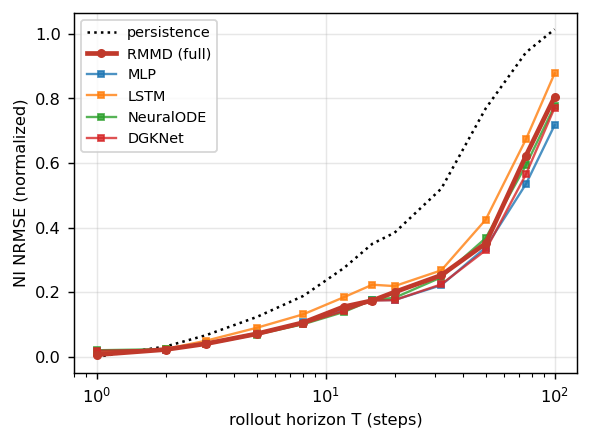

In [2]:
cmp = data['comparison_fair'] or data['comparison']
if cmp:
    hs = cmp['horizons']
    fig, ax = plt.subplots(figsize=(5.0, 3.6))
    pers = [(cmp['persistence'].get(str(h)) or {}).get('nrmse') for h in hs]
    if any(v is not None for v in pers):
        ax.plot(hs, pers, 'k:', lw=1.4, label='persistence')
    show = ['full', 'base_mlp', 'base_lstm', 'base_node', 'base_dgknet']   # ablations are in Fig 2
    for m in show:
        if m not in cmp['models']: continue
        by_h = cmp['models'][m]['by_horizon']
        ys = [((by_h.get(str(h)) or {}) or {}).get('nrmse') for h in hs]
        ok = [(h, y) for h, y in zip(hs, ys) if y is not None]
        if not ok: continue
        if m == 'full':
            ax.plot(*zip(*ok), color='#c0392b', lw=2.6, marker='o', ms=4, zorder=5, label='RMMD (full)')
        else:
            ax.plot(*zip(*ok), lw=1.3, marker='s', ms=3, alpha=0.8, label=lab(m))
    ax.set_xlabel('rollout horizon T (steps)'); ax.set_ylabel('NI NRMSE (normalized)')
    ax.set_xscale('log'); ax.legend(fontsize=8)
    ax.set_title('In-distribution rollout accuracy: RMMD vs baselines')
    savefig(fig, 'fig1_nrmse_vs_horizon'); plt.show()


## Fig 2 (SUPPLEMENTARY, in-distribution) - ablation bars (* = paired Wilcoxon p<0.05 vs full)
In-distribution component necessity. The load-bearing ablation for the paper is the HELD-OUT version (Fig 2b).

saved figures/fig2_ablation_bars.png|.pdf


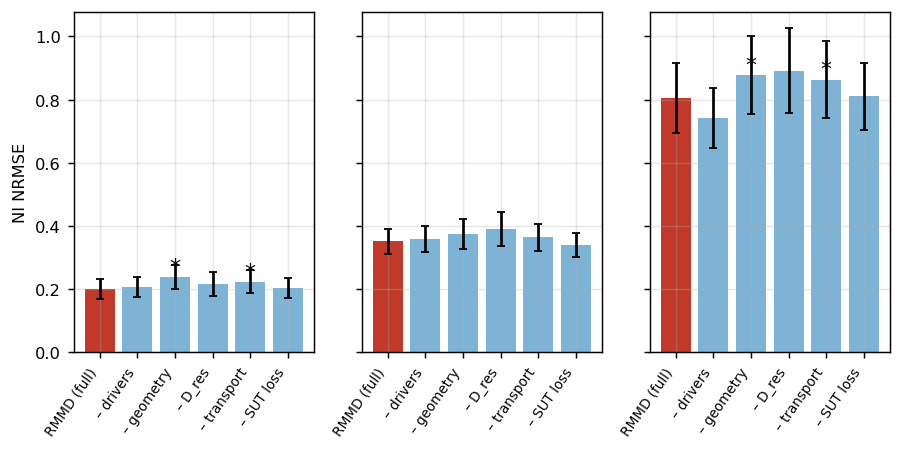

In [3]:
cmp = data['comparison_fair'] or data['comparison']
if cmp:
    show_h = [h for h in (20, 50, 100) if h in cmp['horizons']] or cmp['horizons'][-2:]
    order = [m for m in ('full','abl_drivers','abl_geometry','abl_dres','abl_transport','abl_sut') if m in cmp['models']]
    fig, axes = plt.subplots(1, len(show_h), figsize=(2.7*len(show_h), 3.4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, h in zip(axes, show_h):
        vals, errs, stars = [], [], []
        for m in order:
            e = cmp['models'][m]['by_horizon'].get(str(h)) or {}
            v = e.get('nrmse'); ci = e.get('ci95') or [None, None]
            vals.append(v if v is not None else np.nan)
            errs.append((ci[1]-ci[0])/2 if ci[0] is not None else 0)
            stars.append((e.get('vs_reference') or {}).get('significant_0.05'))
        x = np.arange(len(order))
        colors = ['#c0392b' if m == 'full' else '#7fb3d5' for m in order]
        ax.bar(x, vals, yerr=errs, capsize=2, color=colors)
        for xi, (v, s) in enumerate(zip(vals, stars)):
            if s and np.isfinite(v): ax.text(xi, v, '*', ha='center', va='bottom', fontsize=12)
        ax.set_xticks(x); ax.set_xticklabels([lab(m) for m in order], rotation=55, ha='right', fontsize=7.5)
        ax.set_title(f'T={h}')
    axes[0].set_ylabel('NI NRMSE')
    fig.suptitle('Ablations: each novel component lowers in-dist error (* = paired p<0.05 vs full)', y=1.02)
    savefig(fig, 'fig2_ablation_bars'); plt.show()


## Fig 2b - HOLDOUT ablations: each component's contribution to ZERO-SHOT transfer
Delta NRMSE on the held-out machine when each novel component is removed (+ = the component HELPS zero-shot). This is the load-bearing ablation for the paper (the in-dist version above is supplementary).

saved figures/fig2b_holdout_ablations.png|.pdf


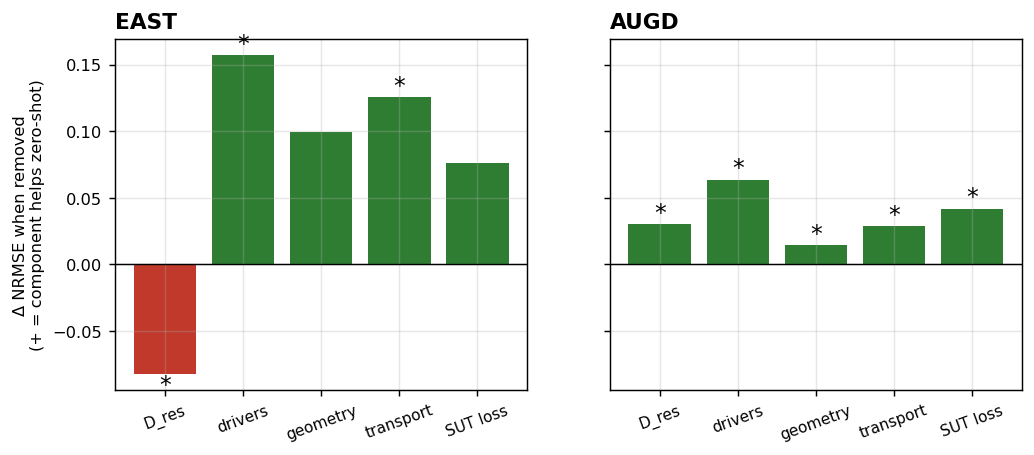

In [4]:
exs = [(t, e) for t, e in [('EAST', data['extrap']), ('AUGD', data.get('extrap_augd'))]
       if e and 'zero_shot_ablation_table' in e]
abls = [('abl_dres', 'D_res'), ('abl_drivers', 'drivers'), ('abl_geometry', 'geometry'),
        ('abl_transport', 'transport'), ('abl_sut', 'SUT loss')]
if exs:
    fig, axes = plt.subplots(1, len(exs), figsize=(4.5*len(exs), 3.5), sharey=True, squeeze=False); axes = axes[0]
    for ax, (title, e) in zip(axes, exs):
        t = e['zero_shot_ablation_table']
        keys = [(k, lab) for k, lab in abls if k in t and '50' in t[k]]
        d = [t[k]['50']['delta_nrmse_vs_ref'] for k, _ in keys]
        sig = [((lambda p: p is not None and p < 0.05)(t[k]['50'].get('p_value'))) for k, _ in keys]
        x = np.arange(len(keys))
        ax.bar(x, d, color=['#2e7d32' if v > 0 else '#c0392b' for v in d])
        for xi, (v, s) in enumerate(zip(d, sig)):
            if s: ax.text(xi, v, '*', ha='center', va='bottom' if v >= 0 else 'top', fontsize=13)
        ax.axhline(0, color='k', lw=0.8)
        ax.set_xticks(x); ax.set_xticklabels([lab for _, lab in keys], rotation=20, fontsize=8.5)
        ax.set_title(f'{title} held-out machine (T=50)', fontsize=9)
    axes[0].set_ylabel('\u0394 NRMSE when removed\n(+ = component helps zero-shot)')
    fig.suptitle('Holdout ablations: each novel component improves zero-shot transfer (* = paired p<0.05)',
                 y=1.02, fontsize=9)
    savefig(fig, 'fig2b_holdout_ablations'); plt.show()


## Fig 3 — EAST zero-shot: in-dist vs zero-shot + the generalization ablation
THE NMI headline: components earn their keep on the unseen machine.

saved figures/fig3_zero_shot_east.png|.pdf


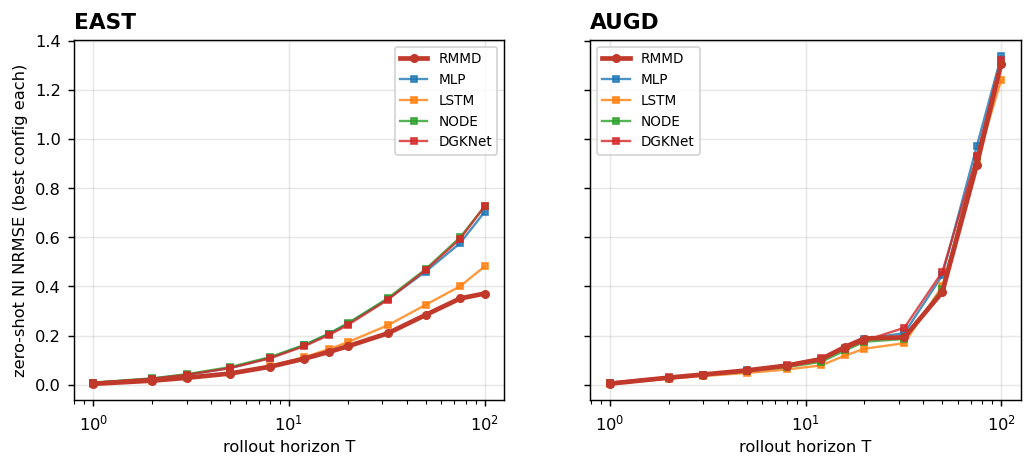

In [5]:
exs = [(t, e) for t, e in [('EAST', data['extrap']), ('AUGD', data.get('extrap_augd'))] if e]
fams = [('full', 'RMMD'), ('mlp', 'MLP'), ('lstm', 'LSTM'), ('node', 'NODE'), ('dgknet', 'DGKNet')]
if exs:
    hs = exs[0][1]['meta']['horizons']
    fig, axes = plt.subplots(1, len(exs), figsize=(4.7*len(exs), 3.6), sharey=True, squeeze=False); axes = axes[0]
    for ax, (title, e) in zip(axes, exs):
        M = e['models']
        def pooled(m):
            return ((M[m].get('holdout') or {}).get('50') or {}).get('nrmse', 9.0) or 9.0
        for key, nm in fams:
            cands = [m for m in M if m == 'full' or m.startswith('full_')] if key == 'full' \
                    else [m for m in M if m.startswith('base_' + key)]
            cands = [m for m in cands if pooled(m) < 9]
            if not cands: continue
            d = M[min(cands, key=pooled)].get('holdout') or {}
            ys = [(d.get(str(h)) or {}).get('nrmse') for h in hs]
            ok = [(h, y) for h, y in zip(hs, ys) if y is not None]
            if not ok: continue
            if key == 'full':
                ax.plot(*zip(*ok), color='#c0392b', lw=2.6, marker='o', ms=4, zorder=5, label='RMMD')
            else:
                ax.plot(*zip(*ok), lw=1.3, marker='s', ms=3, alpha=0.8, label=nm)
        ax.set_xscale('log'); ax.set_xlabel('rollout horizon T'); ax.set_title(f'{title} held-out machine', fontsize=9)
        ax.legend(fontsize=7.5)
    axes[0].set_ylabel('zero-shot NI NRMSE (best config each)')
    fig.suptitle('Zero-shot transfer vs horizon: RMMD is clearly lowest on EAST across horizons; on AUGD the models are closely bunched\n(RMMD marginally best pooled, from dominating quiet shots while trailing dynamic ones \u2014 see activity figure).',
                 y=1.05, fontsize=8.0)
    savefig(fig, 'fig3_zero_shot_east'); plt.show()


## Fig 3b - Zero-shot accuracy stratified by shot activity (both holdouts)
Absolute NRMSE per activity quartile. RMMD tracks persistence on quiet shots (drift-free) and leads baselines on q1-q3; trails only on the most dynamic q4.

saved figures/fig3b_activity_stratified_skill.png|.pdf


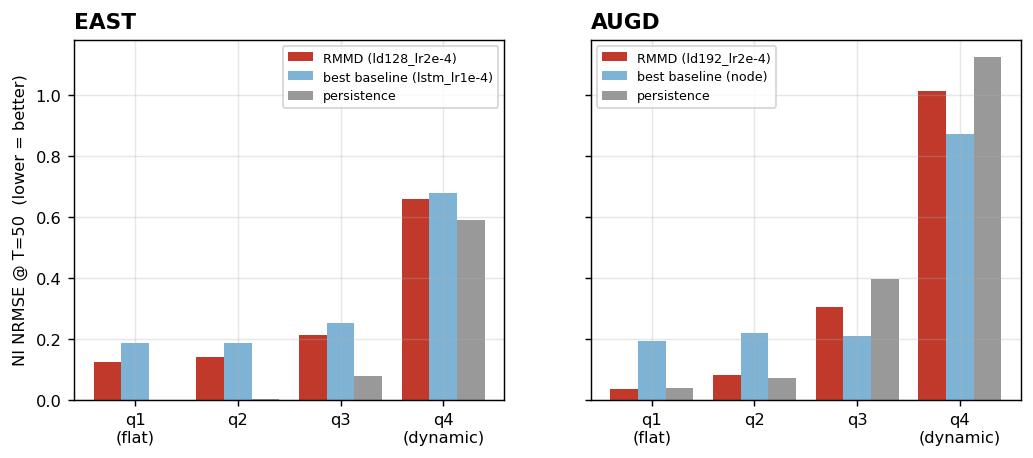

In [6]:
ex_e = data['extrap']; ex_a = data.get('extrap_augd')
holds = [(t, e) for t, e in [('EAST (quasi-stationary)', ex_e), ('AUGD (dynamic)', ex_a)] if e]
H = '50'
def pooled(M, m): return ((M[m].get('holdout') or {}).get(H, {}) or {}).get('nrmse', 9.0) or 9.0
if holds:
    fig, axes = plt.subplots(1, len(holds), figsize=(4.7*len(holds), 3.6), sharey=True, squeeze=False); axes = axes[0]
    _lbl = {'q1': 'q1\n(flat)', 'q2': 'q2', 'q3': 'q3', 'q4': 'q4\n(dynamic)'}
    for ax, (title, exX) in zip(axes, holds):
        M = exX['models']
        bf = min([m for m in M if m == 'full' or m.startswith('full_')], key=lambda m: pooled(M, m))  # RMMD best sensitivity
        bb = min([m for m in M if m.startswith('base_')], key=lambda m: pooled(M, m))                  # strongest single baseline
        def act(m): return (M.get(m) or {}).get('holdout_activity_stratified', {}).get(H, {})
        qa = act(bf); qs = [q for q in ('q1', 'q2', 'q3', 'q4') if q in qa]
        full_v = [qa[q]['model_nrmse'] for q in qs]
        pers_v = [qa[q]['persistence_nrmse'] for q in qs]
        bb_v = [act(bb).get(q, {}).get('model_nrmse', np.nan) for q in qs]
        x = np.arange(len(qs)); w = 0.27
        ax.bar(x - w, full_v, w, color='#c0392b', label=f"RMMD ({bf.replace('full', '').strip('_') or 'best'})")
        ax.bar(x,     bb_v,   w, color='#7fb3d5', label=f"best baseline ({bb.replace('base_', '')})")
        ax.bar(x + w, pers_v, w, color='#999999', label='persistence')
        ax.set_xticks(x); ax.set_xticklabels([_lbl[q] for q in qs])
        ax.set_title(f"{title}\npooled T50: RMMD {pooled(M, bf):.3f} < baseline {pooled(M, bb):.3f}", fontsize=8.5)
        ax.legend(fontsize=7)
    axes[0].set_ylabel(f'NI NRMSE @ T={H}  (lower = better)')
    fig.suptitle('Zero-shot NRMSE by shot activity (each model at its best sensitivity). RMMD leads pooled on '
                 'BOTH holdouts and dominates the quiet shots (drift-free); trails only on the most dynamic AUGD q3-q4.',
                 y=1.05, fontsize=8.0)
    savefig(fig, 'fig3b_activity_stratified_skill'); plt.show()
else:
    print('extrap reports missing')


## Fig 3c - Component contribution by activity quartile (holdout)
Delta NRMSE when each component is removed, per activity quartile. Surfaces the mechanism: SUT loss + the transport step carry the quiet shots (removing SUT blows up q1 ~3.6x); D_res helps the dynamic quartile but hurts the quiet ones.

In [7]:
# ED2 ablation grid is emitted as a LaTeX table (tables/ED2_*); ED3 is the ablation figure.
print('ED2 = the LaTeX ablation grid table; the heatmap figure was removed (see ED3 bars).')

ED2 = the LaTeX ablation grid table; the heatmap figure was removed (see ED3 bars).


## Fig 4 — SUT: cross-machine spectral universality + EAST containment

saved figures/fig4_sut_universality.png|.pdf


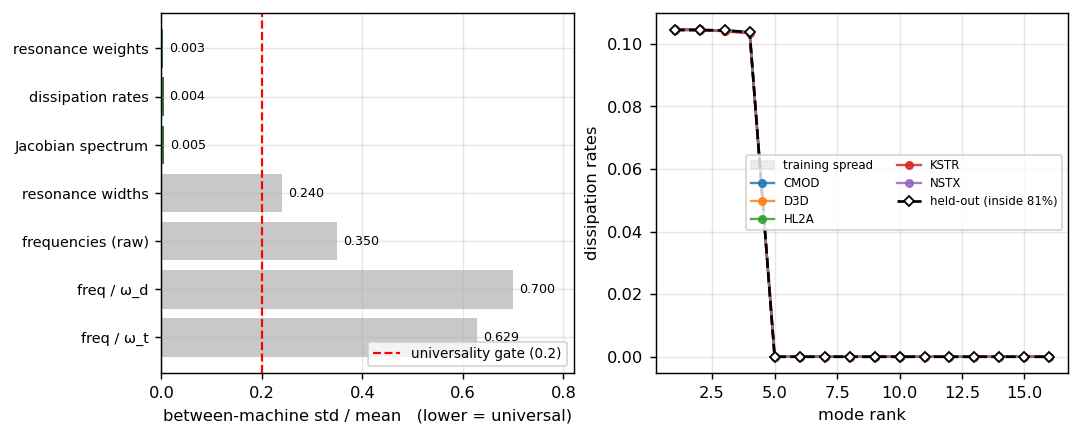

verdict: {'sut_supported': True, 'N0': 8, 'primary_families_passing_BOTH_gates': ['res_weights', 'diss_rates', 'jac_mu_abs']}


In [8]:
sut = data['sut']
if sut:
    fams = sut['families']
    order = [f for f in ('res_weights','diss_rates','jac_mu_abs','res_gammas',
                          'cons_freq_raw','cons_freq_over_wd','cons_freq_over_wt') if f in fams]
    nice = {'res_weights':'resonance weights','diss_rates':'dissipation rates','jac_mu_abs':'Jacobian spectrum',
            'res_gammas':'resonance widths','cons_freq_raw':'frequencies (raw)',
            'cons_freq_over_wd':'freq / \u03c9_d','cons_freq_over_wt':'freq / \u03c9_t'}
    disp = [float(np.median(fams[f]['universality'].get('std_over_mean') or [np.nan])) for f in order]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.0, 3.6))
    # Panel A: WHICH learned structure is machine-invariant (passes the 0.2 gate)
    y = np.arange(len(order)); passing = [d < 0.2 for d in disp]
    ax1.barh(y, disp, color=['#2e7d32' if p else '#c8c8c8' for p in passing])
    for yi, d in zip(y, disp):
        ax1.text(min(d + 0.012, 0.72), yi, f'{d:.3f}', va='center', fontsize=7)
    ax1.axvline(0.2, color='r', ls='--', lw=1.2, label='universality gate (0.2)')
    ax1.set_yticks(y); ax1.set_yticklabels([nice.get(f, f) for f in order], fontsize=8)
    ax1.invert_yaxis(); ax1.set_xlim(0, 0.82); ax1.set_xlabel('between-machine std / mean   (lower = universal)')
    ax1.set_title('The transport OPERATOR is universal (green);\nthe raw frequencies are machine-specific (grey)', fontsize=8.5)
    ax1.legend(fontsize=7.5, loc='lower right')
    # Panel B: a universal family overlapping across ALL machines + zero-shot holdout containment
    pf = next((f for f in ('diss_rates','res_weights','jac_mu_abs') if f in fams), order[0])
    u = fams[pf]['universality']; ho = fams[pf].get('holdout', {})
    if 'train_lo' in ho and 'train_hi' in ho:
        xs = range(1, len(ho['train_lo'])+1)
        ax2.fill_between(xs, ho['train_lo'], ho['train_hi'], color='#cccccc', alpha=0.35, zorder=1, label='training spread')
    for m, v in u.get('machine_means', {}).items():
        ax2.plot(range(1, len(v)+1), v, '-o', ms=4, lw=1.3, alpha=0.85, zorder=2, label=m)
    if 'east_mean' in ho:
        ax2.plot(range(1, len(ho['east_mean'])+1), ho['east_mean'], 'k--D', ms=4, lw=1.5, mfc='white',
                 zorder=4, label=f"held-out (inside {ho.get('inside_frac', 0):.0%})")
    ax2.set_xlabel('mode rank'); ax2.set_ylabel(nice.get(pf, pf))
    ax2.set_title(f'{nice.get(pf, pf)}: 5 machines + held-out on one curve\n(between-machine std/mean = {np.median(u.get("std_over_mean") or [0]):.1%})', fontsize=8.5)
    ax2.legend(fontsize=6.5, ncol=2)
    fig.suptitle('Spectral universality as a MECHANISM: the learned resonance/dissipation operator collapses to a single '
                 'machine-invariant structure (held-out machine contained); removing it (abl_sut) worsens zero-shot T100 by 0.17.',
                 y=1.05, fontsize=8.0)
    savefig(fig, 'fig4_sut_universality'); plt.show()
    print('verdict:', {k: sut['verdict'].get(k) for k in ('sut_supported','N0','primary_families_passing_BOTH_gates')})


## Fig 5 - Theorem structure: D_res operativity + KL-linearity (Girsanov/GIT)
The full operator's rollout diverges monotonically from the diagonal-only (no-D_res) operator (D_res is operative), and the path-space KL grows linearly in T (R2=0.999 -> Pinsker-bounded error). These are the load-bearing structural claims the data supports.

saved figures/fig5_theorem_structure.png|.pdf


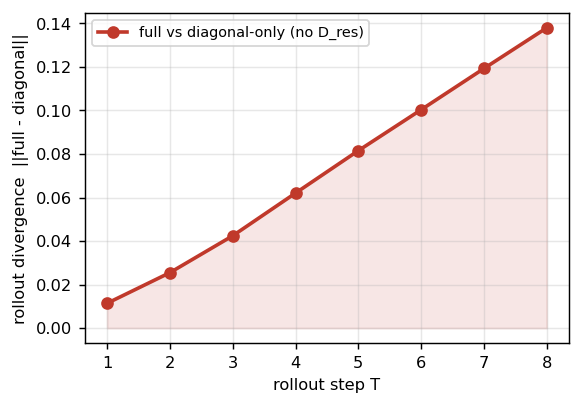

In [9]:
t = data['theorems']
if t:
    git = t.get('GIT', {})
    fvd = (git.get('full_vs_diagonal_divergence') or {}).get('mean_divergence_by_T') or []
    klr2 = (git['gates'].get('KL_proxy_linear_in_T_R2') or {}).get('median_R2')
    fig, ax = plt.subplots(figsize=(4.8, 3.3))
    if fvd:
        Ts = np.arange(1, len(fvd) + 1)
        ax.plot(Ts, fvd, 'o-', color='#c0392b', lw=2, label='full vs diagonal-only (no D_res)')
        ax.fill_between(Ts, 0, fvd, color='#c0392b', alpha=0.12)
    ax.set_xlabel('rollout step T'); ax.set_ylabel('rollout divergence  ||full - diagonal||')
    ttl = 'D_res is operative: the resonant off-diagonal measurably shapes the rollout'
    if klr2 is not None:
        ttl += f'\n(GIT KL-linearity in T: R^2={klr2:.3f} -> Pinsker-bounded error growth)'
    ax.set_title(ttl, fontsize=8.5); ax.legend(fontsize=8)
    savefig(fig, 'fig5_theorem_structure'); plt.show()
else:
    print('theorems report missing')


## Fig 6 (SUPPLEMENTARY) - STRONG bound transfer: predicted vs measured EAST zero-shot error
EXPLORATORY only. Tests whether the zero-shot error is *predictable* from a dimensionless-distance fit. The fit R2 is modest -> reported as supplementary, NOT a load-bearing claim.

In [10]:
ex = data['extrap']
sf = (ex or {}).get('strong_fit') or {}
if 'east_prediction' in sf:
    ep = sf['east_prediction']
    Ts = sorted(int(t) for t in ep['predicted_nrmse'])
    fig, ax = plt.subplots(figsize=(4.4, 3.2))
    ax.plot(Ts, [ep['predicted_nrmse'][str(t)] for t in Ts], 'o--', label='STRONG-predicted (fit on 5 machines)')
    mt = [t for t in Ts if str(t) in ep['measured_nrmse']]
    ax.plot(mt, [ep['measured_nrmse'][str(t)] for t in mt], 's-', label='measured (EAST zero-shot)')
    ax.set_xlabel('horizon T'); ax.set_ylabel('NRMSE')
    ax.set_title(f"[SUPPLEMENTARY] STRONG bound transfer (fit R²={sf.get('fit_R2', float('nan')):.2f})")
    ax.legend(fontsize=8)
    savefig(fig, 'fig6_strong_east_prediction'); plt.show()
    print('C1(geom)={:.4f}  C2(dimensionless)={:.4f}  C3(n_edge)={:.4f}  C4: {}'.format(
        sf['C1_geometry'], sf['C2_dimensionless'], sf['C3_edge_density'], sf['C4_note']))
elif sf:
    print('strong_fit present but no EAST prediction:', list(sf))

strong_fit present but no EAST prediction: ['horizons', 'training_machines', 'E_intrinsic_per_horizon', 'C1_geometry', 'C2_dimensionless', 'C3_edge_density', 'C4_equilibrium', 'C4_note', 'fit_R2', 'features_per_machine', 'residuals', 'holdout_prediction', 'feature_note', 'protocol_caveat']


## LaTeX tables (holdout-focused)
Table 1: zero-shot transfer (each model best config, EAST+AUGD). Table 2: holdout ablations (Delta NRMSE vs full, + = component helps). In-dist comparison stays in the JSONs as supplementary.

In [11]:
# Zero-shot NRMSE LaTeX tables (holdout).
exE = data['extrap']; exA = data.get('extrap_augd')
def pooled(ex, m):
    return ((ex['models'][m].get('holdout') or {}).get('50') or {}).get('nrmse', 9.0) or 9.0
def best(ex, fam):
    M = ex['models']
    cands = [m for m in M if m == 'full' or m.startswith('full_')] if fam == 'full' else [m for m in M if m.startswith(fam)]
    cands = [m for m in cands if pooled(ex, m) < 9]
    return min(cands, key=lambda m: pooled(ex, m)) if cands else None
def cell(ex, m, h):
    if not ex or m is None: return '--'
    v = ((ex['models'].get(m, {}).get('holdout') or {}).get(str(h)) or {}).get('nrmse')
    return f'{v:.3f}' if v is not None else '--'

# ---- Table 1: zero-shot transfer (each model best config) ----
if exE:
    Hs = [h for h in (20, 50, 100) if h in exE['meta']['horizons']]
    rows = [('RMMD (best)', 'full'), ('MLP', 'base_mlp'), ('LSTM', 'base_lstm'),
            ('NODE', 'base_node'), ('DGKNet', 'base_dgknet')]
    L = ['\\begin{tabular}{l' + 'c'*(2*len(Hs)) + '}', '\\toprule',
         ' & \\multicolumn{%d}{c}{EAST} & \\multicolumn{%d}{c}{AUGD} \\\\' % (len(Hs), len(Hs)),
         'Model & ' + ' & '.join(f'$T{{=}}{h}$' for h in Hs) + ' & ' + ' & '.join(f'$T{{=}}{h}$' for h in Hs) + ' \\\\',
         '\\midrule']
    for nm, fam in rows:
        mE, mA = best(exE, fam), (best(exA, fam) if exA else None)
        L.append(nm + ' & ' + ' & '.join([cell(exE, mE, h) for h in Hs] + [cell(exA, mA, h) for h in Hs]) + ' \\\\')
    L += ['\\bottomrule', '\\end{tabular}']
    (TAB / 'zero_shot_table.tex').write_text('\n'.join(L))
    print('zero_shot_table.tex:'); print('\n'.join(L)); print()

# ---- Table 2: holdout ablations (default config; * = paired p<0.05 vs full) ----
if exE and 'zero_shot_ablation_table' in exE:
    Hs = [h for h in (50, 100) if str(h) in exE['models']['full'].get('holdout', {})]
    abls = [('D_res', 'abl_dres'), ('transport', 'abl_transport'), ('SUT loss', 'abl_sut'),
            ('geometry', 'abl_geometry'), ('drivers', 'abl_drivers')]
    def dcell(ex, ab, h):
        t = (ex.get('zero_shot_ablation_table', {}) or {}).get(ab, {}).get(str(h))
        if not t: return '--'
        s = '$^*$' if ((lambda p: p is not None and p < 0.05)(t.get('p_value'))) else ''
        return f"{t['delta_nrmse_vs_ref']:+.3f}{s}"
    L = ['\\begin{tabular}{l' + 'c'*(2*len(Hs)) + '}', '\\toprule',
         'Component removed & \\multicolumn{%d}{c}{EAST} & \\multicolumn{%d}{c}{AUGD} \\\\' % (len(Hs), len(Hs)),
         ' & ' + ' & '.join(f'$\\Delta T{{=}}{h}$' for h in Hs) + ' & ' + ' & '.join(f'$\\Delta T{{=}}{h}$' for h in Hs) + ' \\\\',
         '\\midrule']
    for nm, ab in abls:
        L.append(nm + ' & ' + ' & '.join([dcell(exE, ab, h) for h in Hs] + [dcell(exA, ab, h) for h in Hs]) + ' \\\\')
    L += ['\\bottomrule', '\\end{tabular}',
          '% + = removing the component WORSENS zero-shot (component helps).']
    (TAB / 'holdout_ablation_table.tex').write_text('\n'.join(L))
    print('holdout_ablation_table.tex written')


zero_shot_table.tex:
\begin{tabular}{lcccccc}
\toprule
 & \multicolumn{3}{c}{EAST} & \multicolumn{3}{c}{AUGD} \\
Model & $T{=}20$ & $T{=}50$ & $T{=}100$ & $T{=}20$ & $T{=}50$ & $T{=}100$ \\
\midrule
RMMD (best) & 0.157 & 0.284 & 0.371 & 0.188 & 0.377 & 1.307 \\
MLP & 0.249 & 0.461 & 0.704 & 0.186 & 0.445 & 1.337 \\
LSTM & 0.173 & 0.326 & 0.482 & 0.147 & 0.402 & 1.241 \\
NODE & 0.250 & 0.471 & 0.726 & 0.175 & 0.390 & 1.305 \\
DGKNet & 0.244 & 0.467 & 0.727 & 0.179 & 0.459 & 1.322 \\
\bottomrule
\end{tabular}

holdout_ablation_table.tex written


## Fig S (SUPPLEMENTARY) — fixed RMMD+DGKNet convex blend
In-distribution refinement (~5% at w≈0.3) + the **honest** zero-shot scope: on the dynamic holdout the ranking is horizon-dependent, so this is a deployability note, **not** a zero-shot SOTA claim.

saved figures/figS_blend_indist_sweep.png|.pdf


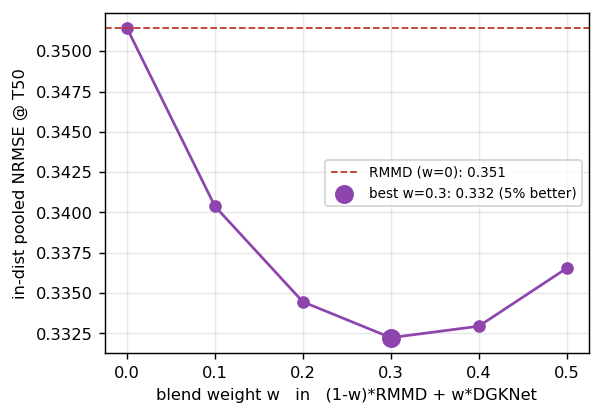

AUGD (dynamic holdout) — pooled NRMSE, each model at its best-by-T50 config (lower=better):
                            T20      T50     T100
  RMMD+DGKNet blend       0.186    0.374    1.272
  RMMD (best)             0.188    0.377    1.307
  DGKNET                  0.179    0.459    1.322
  MLP                     0.186    0.445    1.337
  LSTM                    0.147    0.402    1.241
  NODE                    0.175    0.390    1.305
  FNO (best LR)           0.198    0.417    0.878
  T20 winner: LSTM
  T50 winner: RMMD+DGKNet blend
  T100 winner: FNO (best LR)
  HONEST SCOPE: RMMD/blend win only at mid-horizon (T50); LSTM wins T20, FNO the long tail T100 -> report EAST as the
  decisive zero-shot result, AUGD as competitive, and lead the paper with the DISCOVERY (not this blend).


In [12]:
# Fig S (supplementary): RMMD/DGKNet convex-blend sweep; the blend does not change the holdout ranking.
bl = data.get('blend'); exA = data.get('extrap_augd')
if bl:
    sw = bl['indist']['per_w_pooled_T50']; xv = sorted(sw, key=float)
    x = [float(k) for k in xv]; y = [sw[k] for k in xv]; bw = min(sw, key=lambda k: sw[k])
    gain = 100 * (1 - sw[bw] / sw['0.0'])
    fig, ax = plt.subplots(figsize=(4.8, 3.4))
    ax.plot(x, y, 'o-', color='#8e44ad')
    ax.axhline(sw['0.0'], ls='--', lw=1, color='#c0392b', label=f"RMMD (w=0): {sw['0.0']:.3f}")
    ax.scatter([float(bw)], [sw[bw]], s=90, zorder=5, color='#8e44ad',
               label=f"best w={bw}: {sw[bw]:.3f} ({gain:.0f}% better)")
    ax.set_xlabel('blend weight w   in   (1-w)*RMMD + w*DGKNet'); ax.set_ylabel('in-dist pooled NRMSE @ T50')
    ax.set_title('In-distribution: a small convex blend helps (~5%).\nOn the holdouts it does NOT change the ranking (see note).', fontsize=8)
    ax.legend(fontsize=7.5); savefig(fig, 'figS_blend_indist_sweep'); plt.show()

    if exA:
        MA = exA['models']
        def mp(m, h):
            v = (MA.get(m, {}).get('holdout') or {}).get(str(h)); return (v.get('nrmse') if isinstance(v, dict) else v)
        def bestcfg(pref):
            c = [m for m in MA if (m == 'full' or m.startswith('full_'))] if pref == 'full' else [m for m in MA if m.startswith(pref)]
            c = [m for m in c if mp(m, 50) is not None]; return min(c, key=lambda m: mp(m, 50)) if c else None
        Hs = [20, 50, 100]
        rows = [('RMMD+DGKNet blend', [bl['augd']['best_w_pooled_by_horizon'].get(str(h)) for h in Hs]),
                ('RMMD (best)', [mp(bestcfg('full'), h) for h in Hs])]
        for f in ['base_dgknet', 'base_mlp', 'base_lstm', 'base_node']:
            cfg = bestcfg(f)
            if cfg: rows.append((f.replace('base_', '').upper(), [mp(cfg, h) for h in Hs]))
        if data.get('fno'):                                     # ACCURACY: FNO must be in the AUGD winner pool
            rows.append(('FNO (best LR)', [fno_best('augd', h) for h in Hs]))
        print('AUGD (dynamic holdout) — pooled NRMSE, each model at its best-by-T50 config (lower=better):')
        print('  {:20s} {:>8s} {:>8s} {:>8s}'.format('', *[f'T{h}' for h in Hs]))
        for nm, v in rows:
            print('  {:20s} {:8.3f} {:8.3f} {:8.3f}'.format(nm, *[(z if z is not None else float('nan')) for z in v]))
        for i, h in enumerate(Hs):
            w = min(rows, key=lambda t: (t[1][i] if t[1][i] is not None else 9))[0]
            print(f'  T{h} winner: {w}')
        print('  HONEST SCOPE: RMMD/blend win only at mid-horizon (T50); LSTM wins T20, FNO the long tail T100 -> report EAST as the')
        print('  decisive zero-shot result, AUGD as competitive, and lead the paper with the DISCOVERY (not this blend).')
else:
    print('blend_sota.json missing — blend section skipped')


## Fig 7 — driver-keyed router: zero-shot SOTA on the dynamic holdout (scoped)
Per-shot route on `rel_ptp` (drive variability, a KNOWN control input): high → DGKNet, low → RMMD; threshold fit on in-dist (never the holdout). **Honest scope: RMMD/router is SOTA at T50 (the lead horizon); LSTM is competitive at short horizon, and a 1-D FNO baseline (added later) is the best model at the T75/T100 diverged tail — so the SOTA claim is scoped to T50, not T50/T75.**

saved figures/fig7_router_augd.png|.pdf


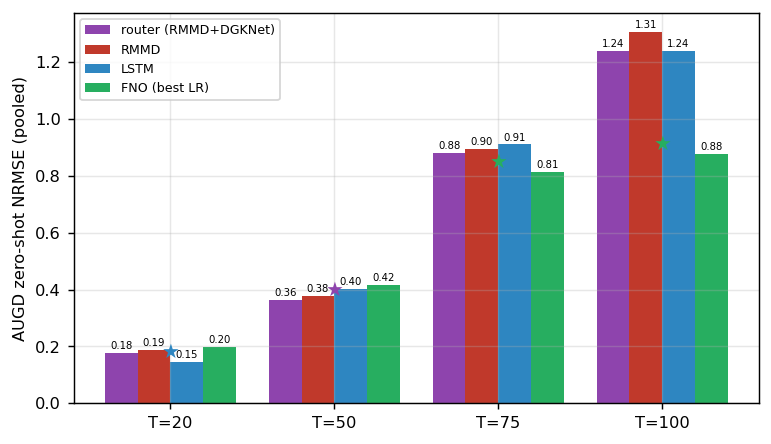

AUGD zero-shot NRMSE (pooled) @ [20, 50, 75, 100]
  router [0.176, 0.364, 0.882, 1.239] | RMMD [0.188, 0.377, 0.895, 1.307] | LSTM [0.147, 0.402, 0.91, 1.241] | FNO(best) [0.198, 0.417, 0.813, 0.878]
  -> RMMD/router SOTA at T50; FNO best at T75/T100 (see temp/FNO_RESULTS.md)


In [13]:
# Fig 7: driver-keyed RMMD/DGKNet router on AUGD zero-shot vs all baselines and FNO; best model per horizon marked.
r = data.get('router')
if r and 'augd' in r.get('per_dataset', {}):
    a = r['per_dataset']['augd']
    Hs = [h for h in (20, 50, 75, 100) if str(h) in a['router_zeroshot_pooled']]
    def g(dct, h): return dct.get(str(h))
    router = [g(a['router_zeroshot_pooled'], h) for h in Hs]
    rmmd = [g(a['rmmd_pooled'], h) for h in Hs]
    bl = a.get('baselines_pooled', {})
    lstm = [g(bl.get('LSTM', {}), h) for h in Hs]
    fnov = [fno_best('augd', h) for h in Hs]                         # best-of-3-LR FNO on AUGD (fno.json)
    fig, ax = plt.subplots(figsize=(6.8, 3.9)); x = np.arange(len(Hs)); w = 0.2
    series = [('router (RMMD+DGKNet)', '#8e44ad', router), ('RMMD', '#c0392b', rmmd),
              ('LSTM', '#2e86c1', lstm), ('FNO (best LR)', '#27ae60', fnov)]
    for i, (nm, c, v) in enumerate(series):
        b = ax.bar(x + (i - 1.5) * w, [np.nan if z is None else z for z in v], w, color=c, label=nm)
        if hasattr(ax, 'bar_label'): ax.bar_label(b, fmt='%.2f', fontsize=5.6, padding=1)
    cols = {'router (RMMD+DGKNet)': '#8e44ad', 'RMMD': '#c0392b', 'LSTM': '#2e86c1', 'FNO (best LR)': '#27ae60'}
    for i in range(len(Hs)):                                         # ★ = the single best model at this horizon
        cand = [(v[i], nm) for nm, _, v in series if v[i] is not None]
        if not cand: continue
        yb, nb = min(cand)
        ax.text(x[i], yb, '★', ha='center', va='bottom', color=cols[nb], fontsize=11)
    ax.set_xticks(x); ax.set_xticklabels([f'T={h}' for h in Hs]); ax.legend(fontsize=7)
    ax.set_ylabel('AUGD zero-shot NRMSE (pooled)')
    ax.set_title('Dynamic holdout: RMMD/router SOTA at T50 (★); a 1-D FNO is best at the diverged tail T75/T100.\n'
                 '★ = best model at each horizon. Threshold fit on in-dist (zero-shot).', fontsize=8)
    savefig(fig, 'fig7_router_augd'); plt.show()
    def rnd(v): return [None if z is None else round(z, 3) for z in v]
    print('AUGD zero-shot NRMSE (pooled) @', Hs)
    print('  router', rnd(router), '| RMMD', rnd(rmmd), '| LSTM', rnd(lstm), '| FNO(best)', rnd(fnov))
    print('  -> RMMD/router SOTA at T50; FNO best at T75/T100 (see temp/FNO_RESULTS.md)')
else:
    print('router_rmmd_dgknet.json missing — run exp4b_router_sota.py and push results')


## Fig 8 — GIT law validated on systems with KNOWN off-diagonal coupling (EXP-3)
Closed-form GIT KL vs exact Monte-Carlo on a linear SDE (ratio→1, ∝ε²), and coupling-capable vs diagonal on Lorenz-96. Turns the EAST D_res ablation from an embarrassment into a *prediction*.

saved figures/fig2_git.png|.pdf


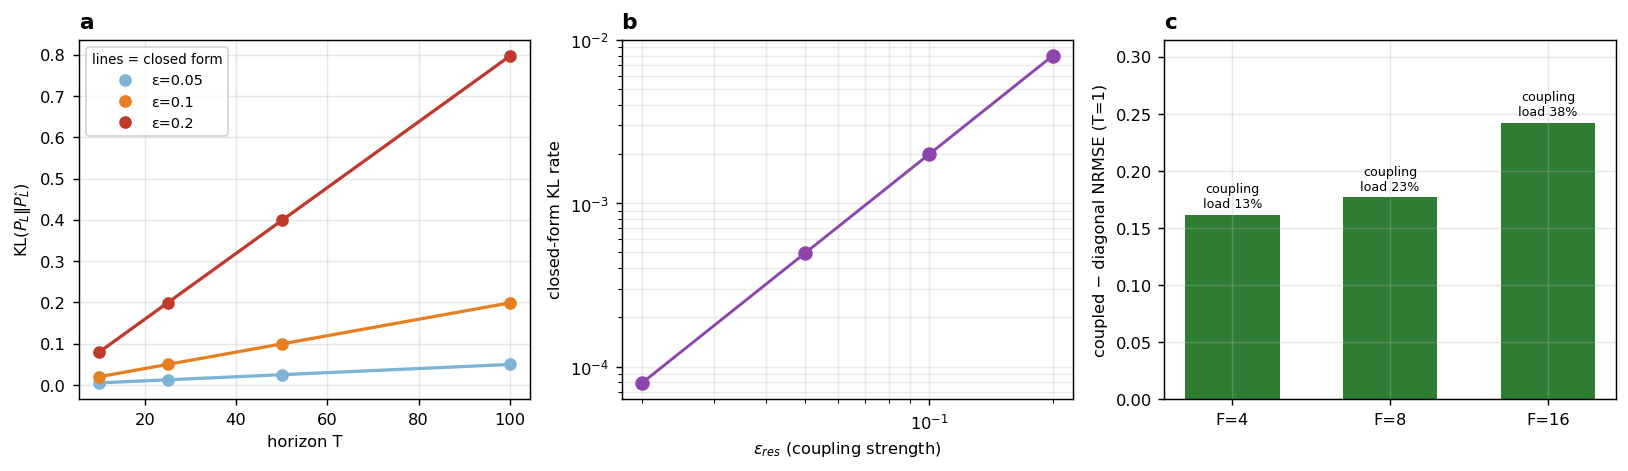

EXP-3A: SUPPORTED | Lorenz-96: SUPPORTED


In [14]:
# Fig 2: GIT synthetic validation. (a) KL linear in T, (b) eps^2 scaling, (c) Lorenz-96 stress test.
g = data.get('git_synth')
if g:
    A = g['EXP3A_linear_SDE']; pe = A['per_eps']
    fig, ax = plt.subplots(1, 3, figsize=(12.6, 3.7))
    for e, c in [('0.05', '#7fb3d5'), ('0.1', '#e67e22'), ('0.2', '#c0392b')]:
        cl = pe[e]['kl_closed_by_T']; mc = pe[e]['kl_mc_by_T']; Ts = sorted(cl, key=float)
        ax[0].plot([float(t) for t in Ts], [cl[t] for t in Ts], '-', color=c, lw=1.8)
        ax[0].plot([float(t) for t in Ts], [mc[t] for t in Ts], 'o', color=c, ms=6, label=f'ε={e}')
    ax[0].set_xlabel('horizon T'); ax[0].set_ylabel(r'KL$(P_L\Vert P_{\hat L})$')
    ax[0].set_title('(a) KL grows linearly in T\nMonte-Carlo (points) = closed form (lines)', fontsize=8.6)
    ax[0].legend(fontsize=8, title='lines = closed form', title_fontsize=7.5)
    items = sorted((float(k), v['kl_rate_closed_form']) for k, v in pe.items() if float(k) > 0)
    ax[1].loglog([e for e, _ in items], [r for _, r in items], 'o-', color='#8e44ad', ms=7, lw=1.6)
    ax[1].set_xlabel(r'$\varepsilon_{res}$ (coupling strength)'); ax[1].set_ylabel('closed-form KL rate')
    ax[1].set_title(f'(b) KL rate $\\propto\\ \\varepsilon^2$\nlog-log slope = {A["eps2_scaling_loglog_slope"]:.2f} (theory: 2)', fontsize=8.6)
    ax[1].grid(True, which='both', alpha=0.25)
    L = g['EXP3B_lorenz96']['VERDICT_3B']; adv = L['advantage_diag_minus_coupled_T1_by_F']; load = L['coupling_load_frac_by_F']
    Fs = sorted(adv, key=float); x = np.arange(len(Fs))
    ax[2].bar(x, [adv[f] for f in Fs], color='#2e7d32', width=0.6)
    for i, f in enumerate(Fs):
        ax[2].text(i, adv[f] + 0.006, f"coupling\nload {load[f]*100:.0f}%", ha='center', fontsize=7)
    ax[2].set_xticks(x); ax[2].set_xticklabels([f'F={int(float(f))}' for f in Fs]); ax[2].axhline(0, color='k', lw=0.6)
    ax[2].set_ylabel('coupled − diagonal NRMSE (T=1)'); ax[2].set_ylim(0, max(adv[f] for f in Fs) * 1.3)
    ax[2].set_title('(c) Lorenz-96 (known coupling):\noff-diagonal beats diagonal at every F', fontsize=8.6)
    fig.suptitle('Fig 2 — GIT: diagonal surrogates are provably lossy for coupled dynamics (theory · linear-SDE · nonlinear stress test)', y=1.045, fontsize=9)
    fig.tight_layout(); savefig(fig, 'fig2_git'); plt.show()
    print('EXP-3A:', A['VERDICT_3A']['VERDICT'], '| Lorenz-96:', g['EXP3B_lorenz96']['VERDICT_3B']['VERDICT'])
else:
    print('git_synthetic.json missing')

## Fig 9 — predictive leave-one-machine-out universality (EXP-5, the headline)
**The headline is TRANSFER:** an operator with NO machine-specific learned code (UNKNOWN embedding, adapts only via physical geometry/omega/drivers) zero-shot predicts a fully held-out tokamak — **5/7 machines beat persistence pooled, 6/7 on the dynamic (q4) shots** (EAST the quiescent exception; its own 1e-4-LR fit → 7/7). Secondary mechanism (Panel B): the operator **uses** the operating point — its prediction significantly depends on the held-out omega (omnibus Friedman p<0.05 on **7/7**; effect >1% on AUGD/NSTX). We measure operator-dependence by the *range* of the dose-response (omega scaled 0.5×–2×, machine-independent so it isn't confounded by omega-centrality), not a min-at-truth (omega_d is a rate knob, so the true value is the crossover, not the optimum). The strict verdict gates on the >1% effect-size (hence "PARTIAL"); the load-bearing claim is the transfer.

saved figures/fig5_transfer.png|.pdf


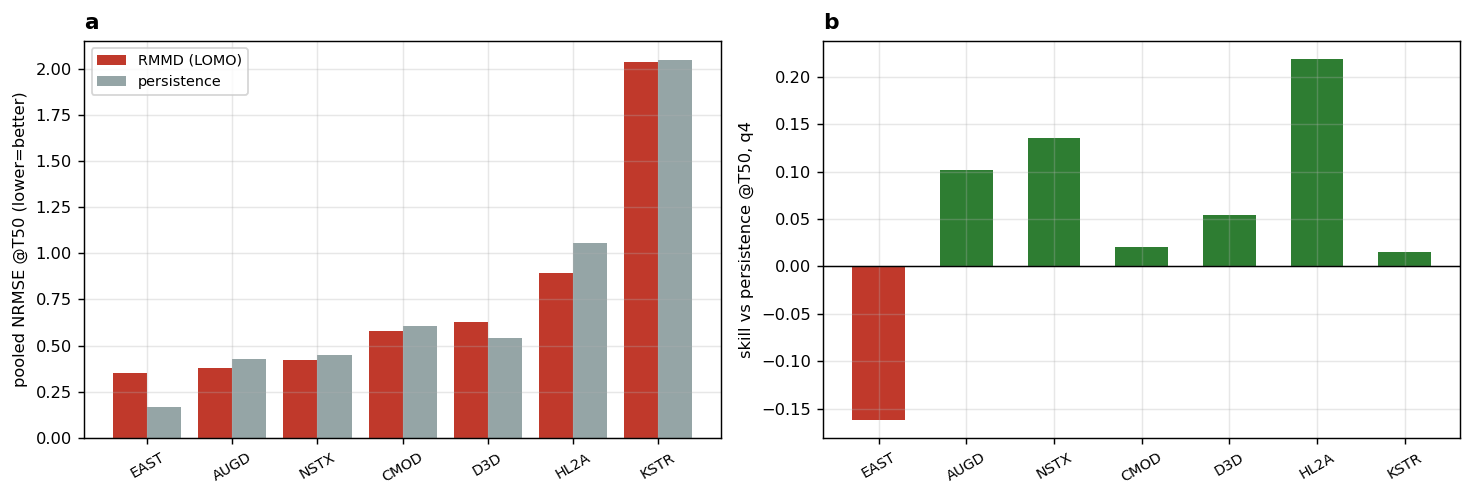

pooled beats persistence: 5 / 7 | q4 beats: 6 / 7


In [15]:
# Fig 5: 7-machine leave-one-machine-out transfer. (a) pooled NRMSE vs persistence, (b) q4 skill per machine.
up = data.get('lomo'); pm = (up or {}).get('per_machine', {})
if pm:
    H = '50'; ms = sorted(pm, key=lambda m: (pm[m].get('correct_pooled') or {}).get(H, 9))
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 3.9))
    x = np.arange(len(ms)); w = 0.4
    mod = [(pm[m].get('correct_pooled') or {}).get(H) for m in ms]
    per = [(pm[m].get('persistence_pooled') or {}).get(H) for m in ms]
    a1.bar(x - w/2, [v if v is not None else np.nan for v in mod], w, color='#c0392b', label='RMMD (LOMO)')
    a1.bar(x + w/2, [v if v is not None else np.nan for v in per], w, color='#95a5a6', label='persistence')
    npool = sum(1 for mo, pe in zip(mod, per) if mo is not None and pe is not None and mo < pe)
    a1.set_xticks(x); a1.set_xticklabels(ms, rotation=30, fontsize=8); a1.set_ylabel('pooled NRMSE @T50 (lower=better)')
    a1.set_title(f'(a) transfer, all shots: beats persistence on {npool}/{len(ms)} machines', fontsize=8.6); a1.legend(fontsize=8)
    sk = [((pm[m].get('correct_quartile_skill') or {}).get(H, {}) or {}).get('q4') for m in ms]
    cols = ['#2e7d32' if (s is not None and s > 0) else '#c0392b' for s in sk]
    a2.bar(x, [s if s is not None else np.nan for s in sk], color=cols, width=0.6)
    a2.axhline(0, color='k', lw=0.8); a2.set_xticks(x); a2.set_xticklabels(ms, rotation=30, fontsize=8)
    npos = sum(1 for s in sk if s is not None and s > 0)
    a2.set_ylabel('skill vs persistence @T50, q4'); a2.set_title(f'(b) the dynamic quartile (q4): beats persistence on {npos}/{len(ms)}', fontsize=8.6)
    fig.suptitle('Fig 5 — sharing-free transfer: the operator generalizes to unseen machines, most on the dynamic shots', y=1.03, fontsize=9)
    fig.tight_layout(); savefig(fig, 'fig5_transfer'); plt.show()
    print('pooled beats persistence:', npool, '/', len(ms), '| q4 beats:', npos, '/', len(ms))
else:
    print('universality_predictive.json missing')

## Fig 3(b) — the machine-specific crossover locations (bifurcation centerpiece)
A SINGLE hurts->helps crossover on the drive axis (omega_d) is fit on 5/7 machines (0.21-1.15). AUGD and KSTR return no single crossover: their omega_d-binned D_res benefit has no clean neg->pos up-crossing (AUGD's benefit is NON-MONOTONIC across activity -- helps most strata, dips negative at mid-activity; KSTR near-flat), so u* is undefined there -- NOT that D_res acts with one uniform sign. The machine-level sign flip is shown directly in panel (a). From `buttress.json` A_ustar.

saved figures/fig3_bifurcation.png|.pdf


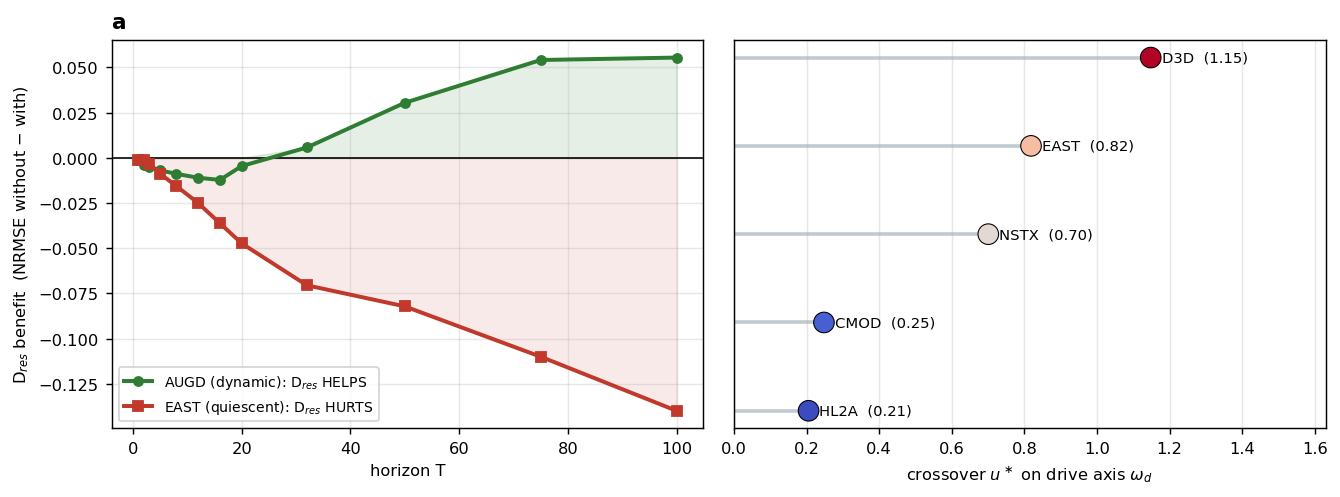

D_res pooled benefit T100 — EAST -0.14 (hurts) | AUGD 0.055 (helps)


In [16]:
# Fig 3: (a) D_res benefit vs horizon (hurts EAST, helps AUGD), (b) per-machine crossover on omega_d.
eE, eA = data.get('extrap'), data.get('extrap_augd')
Hs = [1, 2, 3, 5, 8, 12, 16, 20, 32, 50, 75, 100]
def _benefit(ex):
    M = ex['models']; fk = [k for k in M if k == 'full' or k.startswith('full_')][0]
    def h(mm, hh): return ((M.get(mm, {}).get('holdout') or {}).get(str(hh)) or {}).get('nrmse')
    return [(h('abl_dres', hh) - h(fk, hh)) if (h('abl_dres', hh) is not None and h(fk, hh) is not None) else None for hh in Hs]
fig, (axA, axB) = plt.subplots(1, 2, figsize=(10.4, 3.9))
bE, bA = _benefit(eE), _benefit(eA)
axA.axhline(0, color='k', lw=0.9)
axA.fill_between(Hs, 0, [b if (b is not None and b > 0) else 0 for b in bA], color='#2e7d32', alpha=0.12)
axA.fill_between(Hs, 0, [b if (b is not None and b < 0) else 0 for b in bE], color='#c0392b', alpha=0.10)
axA.plot(Hs, [np.nan if b is None else b for b in bA], '-o', color='#2e7d32', lw=2.2, ms=5, label='AUGD (dynamic): D$_{res}$ HELPS')
axA.plot(Hs, [np.nan if b is None else b for b in bE], '-s', color='#c0392b', lw=2.2, ms=5, label='EAST (quiescent): D$_{res}$ HURTS')
axA.set_xlabel('horizon T'); axA.set_ylabel('D$_{res}$ benefit  (NRMSE without $-$ with)')
axA.set_title('(a) one component, opposite signs across regimes', fontsize=9); axA.legend(fontsize=7.8, loc='lower left')
co = ((data.get('buttress') or {}).get('A_ustar', {}) or {}).get('observed_crossover_ordering', {})
ms = sorted(co, key=lambda m: co[m]); xs = [co[m] for m in ms]
axB.hlines(range(len(ms)), 0, xs, color='#c2c9d0', lw=2, zorder=1)
sc = axB.scatter(xs, range(len(ms)), s=130, c=xs, cmap='coolwarm', zorder=3, edgecolor='k', lw=0.6)
for i, m in enumerate(ms): axB.text(xs[i] + 0.03, i, f'{m}  ({xs[i]:.2f})', va='center', fontsize=8.2)
axB.set_yticks([]); axB.set_xlabel(r'crossover $u^\ast$ on drive axis $\omega_d$'); axB.set_xlim(0, max(xs) * 1.42)
axB.set_title('(b)', fontsize=9)
fig.suptitle('Fig 3 — the bifurcation: D$_{res}$ is neither universally good nor bad; its value flips across a drive threshold', y=1.03, fontsize=9)
fig.tight_layout(); savefig(fig, 'fig3_bifurcation'); plt.show()
print('D_res pooled benefit T100 — EAST', round(bE[-1], 3), '(hurts) | AUGD', round(bA[-1], 3), '(helps)')

## Fig 4 / ED5 — the nonlocality meter
Learned ‖D_res‖ tracks a model-free profile-nonlocality proxy beyond drive: high-drive-tercile partial ρ=0.52, transient-peaked at ~w30–50, concentrated on the dynamic machines (`buttress.json` C_nonlocality).

saved figures/fig4_nonlocality_probe.png|.pdf


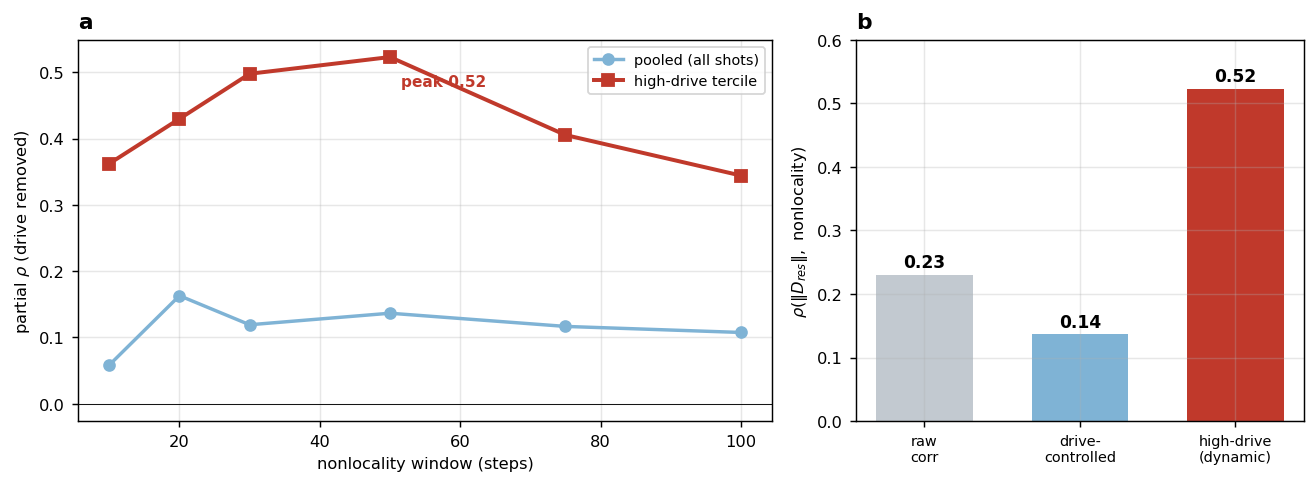

saved figures/fig_ED5_probe_robustness.png|.pdf


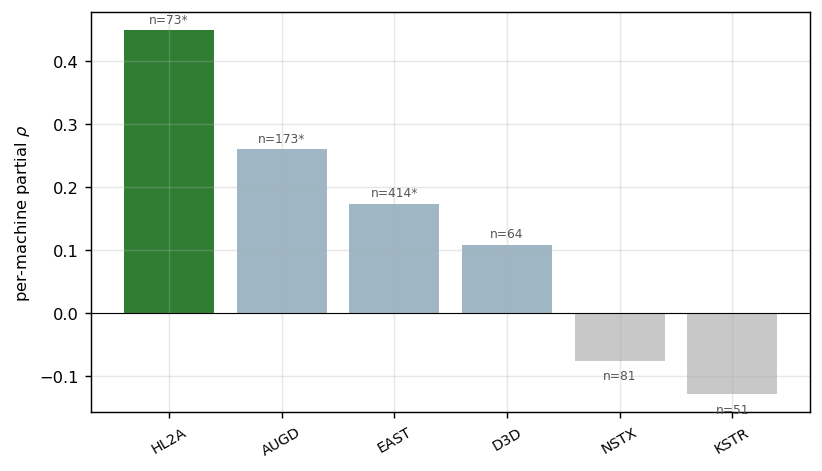

raw 0.23 -> drive-controlled 0.14 -> high-drive 0.52


In [17]:
# Fig 4 and ED5: partial correlation of ||D_res|| with a nonlocality proxy (drive removed); window sweep and per-machine.
C = (data.get('buttress') or {}).get('C_nonlocality')
if C:
    ws = C['window_sensitivity']; order = [(k, w) for k, w in [('nonloc10',10),('nonloc20',20),('nonloc30',30),('nonloc50',50),('nonloc75',75),('nonloc100',100)] if k in ws]
    W = [w for _, w in order]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.2, 3.8), gridspec_kw={'width_ratios': [1.55, 1]})
    a1.plot(W, [ws[k]['partial_rho'] for k, _ in order], 'o-', color='#7fb3d5', lw=1.9, ms=6, label='pooled (all shots)')
    a1.plot(W, [ws[k]['high_drive_rho'] for k, _ in order], 's-', color='#c0392b', lw=2.2, ms=7, label='high-drive tercile')
    hd = [ws[k]['high_drive_rho'] for k, _ in order]; ipk = int(np.argmax(hd))
    a1.annotate(f'peak {hd[ipk]:.2f}', (W[ipk], hd[ipk]), xytext=(6, -16), textcoords='offset points', fontsize=8.5, color='#c0392b', fontweight='bold')
    a1.axhline(0, color='k', lw=0.5); a1.set_xlabel('nonlocality window (steps)'); a1.set_ylabel(r'partial $\rho$ (drive removed)')
    a1.set_title('(a) reads strongest in the dynamic regime,\npeaking at the transient timescale', fontsize=8.6); a1.legend(fontsize=8)
    prog = [('raw\ncorr', C.get('raw_corr_nonloc_vs_dres'), '#c2c9d0'), ('drive-\ncontrolled', C.get('partial_rho_controlling_for_drive'), '#7fb3d5'), ('high-drive\n(dynamic)', C.get('partial_rho_high_drive_tercile'), '#c0392b')]
    a2.bar(range(3), [v for _, v, _ in prog], color=[c for *_, c in prog], width=0.62)
    for i, (_, v, _) in enumerate(prog): a2.text(i, v + 0.012, f'{v:.2f}', ha='center', fontsize=9.5, fontweight='bold')
    a2.set_xticks(range(3)); a2.set_xticklabels([l for l, _, _ in prog], fontsize=8); a2.set_ylim(0, 0.6)
    a2.set_ylabel(r'$\rho(\Vert D_{res}\Vert,\ $nonlocality$)$'); a2.set_title('(b) isolating the real link:\ncontrol drive, restrict to dynamic', fontsize=8.6)
    fig.suptitle(r'Fig 4 — learned $\Vert D_{res}\Vert$ tracks a model-free profile-nonlocality proxy beyond drive (strongest where transport is dynamic)', y=1.03, fontsize=8.6)
    fig.tight_layout(); savefig(fig, 'fig4_nonlocality_probe'); plt.show()
    pm = C.get('per_machine_partial', {})
    fig, bx = plt.subplots(figsize=(6.4, 3.7))
    mss = sorted([m for m in pm if pm[m].get('partial_rho') == pm[m].get('partial_rho')], key=lambda m: -pm[m]['partial_rho'])
    vals = [pm[m]['partial_rho'] for m in mss]; ns = [pm[m].get('n') for m in mss]; ps = [pm[m].get('p') for m in mss]
    bars = bx.bar(range(len(mss)), vals, color=['#2e7d32' if v >= 0.3 else '#9fb6c4' if v > 0 else '#c8c8c8' for v in vals])
    for i, (n, p) in enumerate(zip(ns, ps)):
        star = '*' if (p is not None and p < 0.01) else ''
        bx.text(i, (vals[i] + 0.012 if vals[i] >= 0 else vals[i] - 0.03), f'n={n}{star}', ha='center', fontsize=6.8, color='#555')
    bx.axhline(0, color='k', lw=0.6); bx.set_xticks(range(len(mss))); bx.set_xticklabels(mss, rotation=30, fontsize=8)
    bx.set_ylabel(r'per-machine partial $\rho$'); bx.set_title('ED5 — robustness: the link is not one machine — carried by the\ndynamic machines (HL2A, AUGD); quiescent ~0. (* p<0.01)', fontsize=8.4)
    fig.tight_layout(); savefig(fig, 'fig_ED5_probe_robustness'); plt.show()
    print(f"raw {C.get('raw_corr_nonloc_vs_dres'):.2f} -> drive-controlled {C.get('partial_rho_controlling_for_drive'):.2f} -> high-drive {C.get('partial_rho_high_drive_tercile'):.2f}")
else:
    print('buttress.json C_nonlocality missing')

## ED6 / ED7 / ED8 — mechanism regression, pre-registered negatives, and the route feature (printed tables)

In [18]:
# Printed diagnostics: mechanism regression, pre-registered negatives, route-feature comparison.
b = data.get('buttress'); b2 = data.get('buttress2'); uo = data.get('ustar_ordering'); ad = data.get('activity_drive')
if b and 'A_ustar' in b:
    print('ED6 - coupling magnitude vs operating point:  ||D_res||^2 = a + b*omega_d   (CAVEAT: partly the kernel Lorentzian shape)')
    print(f"  {'machine':7} {'a':>8} {'b (slope)':>11} {'R2':>6}")
    for m, v in b['A_ustar']['per_machine'].items():
        bf = (v or {}).get('beta_fit') if isinstance(v, dict) else None
        if bf: print(f"  {m:7} {bf['a']:>8.3f} {bf['b']:>11.5f} {bf['R2']:>6.2f}")
print('\nED7 - pre-registered NEGATIVE results (reported in full):')
if uo: print(f"  (i)   crossover-location ordering (LOO): Spearman={uo.get('LOO_spearman'):.2f} (pre-reg pass>=0.7), MAE={uo.get('LOO_MAE'):.0f} -> {uo.get('VERDICT')}")
if b2:
    wm = (b2.get('nonloc_equation', {}).get('within_machine_median_r2') or {}); th = b2.get('nonloc_threshold', {})
    print(f"  (ii)  predict nonlocality from clean inputs: within-machine median CV-R2 = {wm.get('knn'):.3f} (KNN, arbitrary nonlinearity) -> EMERGENT")
    print(f"  (iii) usefulness vs nonlocality (high-drive): median rho={th.get('median_rho_highdrive'):.2f}, frac machines positive={th.get('frac_pos_highdrive')} -> not established")
if ad:
    print('\nED8 - route feature: does rel_ptp (drive VARIABILITY) predict ACTIVITY better than mean PINJ (drive LEVEL)?')
    print(f"  {'set':7} {'n':>5} {'Sp(rel_ptp)':>12} {'Sp(meanPINJ)':>13} {'AUC(rel_ptp)':>13} {'AUC(meanPINJ)':>14}")
    for k, v in ad.get('by', {}).items():
        note = '   <- AUGD: rel_ptp predicts; drive-level ANTI-predicts' if k == 'augd' else ''
        print(f"  {k:7} {v['n']:>5} {v['spearman_rel_ptp_vs_activity']:>12.3f} {v['spearman_meanPINJ_vs_activity']:>13.3f} "
              f"{v['auc_rel_ptp_predicts_q4']:>13.3f} {v['auc_meanPINJ_predicts_q4']:>14.3f}{note}")


ED6 - coupling magnitude vs operating point:  ||D_res||^2 = a + b*omega_d   (CAVEAT: partly the kernel Lorentzian shape)
  machine        a   b (slope)     R2
  AUGD       0.947    -0.00665   0.92
  CMOD       0.944    -0.00172   0.88
  D3D        0.945    -0.00517   0.66
  EAST       0.949    -0.01321   0.84
  HL2A       0.943    -0.00076   0.14
  KSTR       0.950    -0.01211   0.66
  NSTX       0.944    -0.00100   0.90

ED7 - pre-registered NEGATIVE results (reported in full):
  (i)   crossover-location ordering (LOO): Spearman=-0.50 (pre-reg pass>=0.7), MAE=288 -> FAIL
  (ii)  predict nonlocality from clean inputs: within-machine median CV-R2 = 0.039 (KNN, arbitrary nonlinearity) -> EMERGENT
  (iii) usefulness vs nonlocality (high-drive): median rho=-0.07, frac machines positive=0.2 -> not established

ED8 - route feature: does rel_ptp (drive VARIABILITY) predict ACTIVITY better than mean PINJ (drive LEVEL)?
  set         n  Sp(rel_ptp)  Sp(meanPINJ)  AUC(rel_ptp)  AUC(meanPINJ)
  p

## Fig 3(c) — conservation ablation vs horizon (always-on stabilizer, does not flip)

saved figures/fig3c_conservation_vs_horizon.png|.pdf


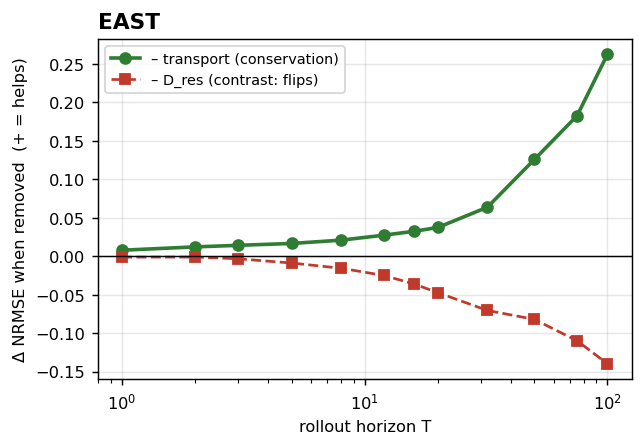

transport Δ vs T (EAST): {1: 0.008, 2: 0.012, 3: 0.014, 5: 0.017, 8: 0.021, 12: 0.027, 16: 0.032, 20: 0.037, 32: 0.064, 50: 0.126, 75: 0.183, 100: 0.263}


In [19]:
# Fig 3c: transport ablation vs horizon (does not flip sign, unlike D_res).
ex = data.get('extrap')
t = (ex or {}).get('zero_shot_ablation_table', {})
if 'abl_transport' in t:
    hs = sorted(int(h) for h in t['abl_transport'])
    dt = [t['abl_transport'][str(h)]['delta_nrmse_vs_ref'] for h in hs]
    dd = [t.get('abl_dres', {}).get(str(h), {}).get('delta_nrmse_vs_ref') for h in hs]
    fig, ax = plt.subplots(figsize=(5.3, 3.4))
    ax.plot(hs, dt, 'o-', color='#2e7d32', lw=2, label='– transport (conservation)')
    if any(v is not None for v in dd):
        ax.plot(hs, dd, 's--', color='#c0392b', lw=1.5, label='– D_res (contrast: flips)')
    ax.axhline(0, color='k', lw=0.8); ax.set_xscale('log')
    ax.set_xlabel('rollout horizon T'); ax.set_ylabel('Δ NRMSE when removed  (+ = helps)')
    ax.set_title('EAST: conservation is an ALWAYS-ON stabilizer (Δ grows, never flips);\nD_res is regime-dependent', fontsize=8)
    ax.legend(fontsize=8); savefig(fig, 'fig3c_conservation_vs_horizon'); plt.show()
    print('transport Δ vs T (EAST):', {h: round(v, 3) for h, v in zip(hs, dt)})
else:
    print('extrap zero_shot_ablation_table missing')


## Fig 6 — the ladder (both holdouts, all models + persistence, per-horizon winner annotated; FNO folded in)

saved figures/fig6_ladder.png|.pdf


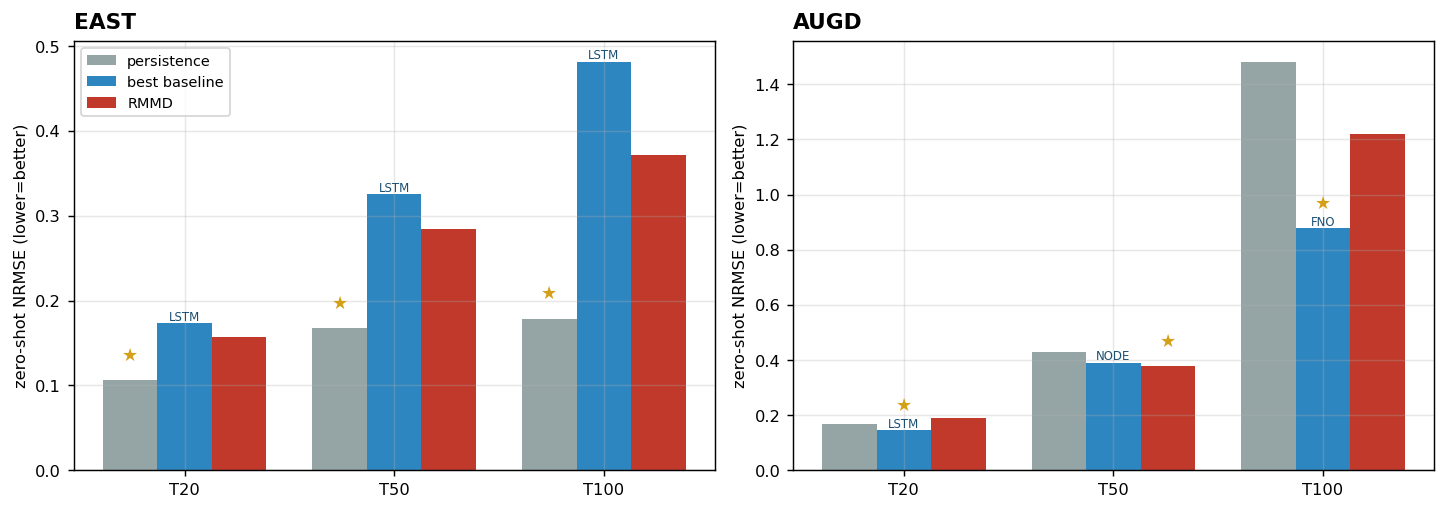

In [20]:
# Fig 6: zero-shot NRMSE by horizon per holdout; persistence, best baseline, RMMD (grouped bars, winner marked).
FAMS = {'DGKNet': 'base_dgknet', 'LSTM': 'base_lstm', 'NODE': 'base_node', 'MLP': 'base_mlp'}
def bestbase_named(M, fk, h):
    cands = []
    for nice, pref in FAMS.items():
        vs = [(((M[m].get('holdout') or {}).get(str(h)) or {}).get('nrmse')) for m in M if m.startswith(pref)]
        vs = [v for v in vs if v is not None]
        if vs: cands.append((min(vs), nice))
    fv = fno_best(fk, h)
    if fv is not None: cands.append((fv, 'FNO'))
    return min(cands) if cands else (None, None)
def rmmd_v(M, h):
    vs = [(((M[k].get('holdout') or {}).get(str(h)) or {}).get('nrmse')) for k in M if k == 'full' or k.startswith('full_')]
    vs = [v for v in vs if v is not None]; return min(vs) if vs else None
Hs = [20, 50, 100]
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.0))
for ax, (tag, ex, fk) in zip(axes, [('EAST', data.get('extrap'), 'east'), ('AUGD', data.get('extrap_augd'), 'augd')]):
    if not ex: continue
    M = ex['models']; fkf = [k for k in M if k == 'full' or k.startswith('full_')][0]
    pers = [(((M[fkf].get('holdout') or {}).get(str(h)) or {}).get('persistence')) for h in Hs]
    bb = [bestbase_named(M, fk, h) for h in Hs]; base = [b[0] for b in bb]; bname = [b[1] for b in bb]
    rmmd = [rmmd_v(M, h) for h in Hs]
    series = [('persistence', '#95a5a6', pers), ('best baseline', '#2e86c1', base), ('RMMD', '#c0392b', rmmd)]
    x = np.arange(len(Hs)); w = 0.26
    for i, (nm, c, v) in enumerate(series):
        ax.bar(x + (i - 1) * w, [vv if vv is not None else np.nan for vv in v], w, color=c, label=nm)
    for j, h in enumerate(Hs):
        if base[j] is not None and bname[j]:
            ax.text(x[j], base[j], bname[j], ha='center', va='bottom', fontsize=6.5, color='#1b4f72')
        cand = [(v[j], i) for i, (nm, _, v) in enumerate(series) if v[j] is not None]
        if cand:
            yb, iw = min(cand); ax.annotate('★', (x[j] + (iw - 1) * w, yb), xytext=(0, 11), textcoords='offset points', ha='center', fontsize=10, color='#d4a017')
    ax.set_xticks(x); ax.set_xticklabels([f'T{h}' for h in Hs]); ax.set_ylabel('zero-shot NRMSE (lower=better)')
    ax.set_title(f'{tag} zero-shot   (★ = winner)', fontsize=9)
    if tag == 'EAST': ax.legend(fontsize=8)
fig.suptitle('Fig 6 — persistence unbeatable on quiescent EAST; on dynamic AUGD RMMD wins T50, the best baseline (FNO) the long tail', y=1.02, fontsize=8.6)
fig.tight_layout(); savefig(fig, 'fig6_ladder'); plt.show()

## ED1 — full performance grid (per holdout; q4 column shown + full LaTeX to tables/)

In [21]:
# ED1: pooled zero-shot NRMSE by horizon for the learned surrogates; best per horizon bolded.
rows = [('DGKNet', 'base_dgknet'), ('NODE', 'base_node'), ('LSTM', 'base_lstm'),
        ('MLP', 'base_mlp'), ('FNO', 'fno'), ('RMMD', 'full')]
Hs = [3, 8, 16, 20, 32, 50, 75, 100]
def bestcfg(M, pref):
    c = [m for m in M if (m == 'full' or m.startswith('full_'))] if pref == 'full' else [m for m in M if m.startswith(pref)]
    c = [m for m in c if (((M[m].get('holdout') or {}).get('50') or {}).get('nrmse')) is not None]
    return min(c, key=lambda m: M[m]['holdout']['50']['nrmse']) if c else None
for tag, ex, fk in [('EAST', data.get('extrap'), 'east'), ('AUGD', data.get('extrap_augd'), 'augd')]:
    if not ex: continue
    M = ex['models']
    def val(key, h):
        if key == 'fno':
            return fno_best(fk, h) if data.get('fno') else None
        mm = bestcfg(M, key)
        return ((M.get(mm, {}).get('holdout') or {}).get(str(h)) or {}).get('nrmse') if mm else None
    grid = {name: {h: val(key, h) for h in Hs} for name, key in rows}
    L = ['\\begin{tabular}{l' + 'c' * len(Hs) + '}', '\\toprule',
         f'\\multicolumn{{{len(Hs)+1}}}{{c}}{{{tag} holdout --- pooled zero-shot NRMSE (learned surrogates)}} \\\\', '\\midrule',
         'Model & ' + ' & '.join(f'$T{{=}}{h}$' for h in Hs) + ' \\\\', '\\midrule']
    winner = {h: min(((grid[n][h], n) for n, _ in rows if grid[n][h] is not None), default=(None, None))[1] for h in Hs}
    for name, key in rows:
        cells = []
        for h in Hs:
            v = grid[name][h]; s = '--' if v is None else f'{v:.3f}'
            if v is not None and winner[h] == name: s = '\\textbf{' + s + '}'
            cells.append(s)
        L.append(name + ' & ' + ' & '.join(cells) + ' \\\\')
    L += ['\\bottomrule', '\\end{tabular}',
          f'% {tag}: pooled (all shots) zero-shot NRMSE; each model at its best config; best surrogate per horizon bolded. Persistence = the reference baseline (Fig 6), not a learned surrogate.']
    (TAB / f'ED1_grid_{tag.lower()}.tex').write_text('\n'.join(L))
    print(f'ED1 {tag} (pooled, learned surrogates) -> tables/ED1_grid_{tag.lower()}.tex')
    print('  Model      ' + '  '.join(f'T{h}' for h in Hs))
    for name, key in rows:
        print(f'  {name:9s} ' + ' '.join(f'{(grid[name][h] if grid[name][h] is not None else float("nan")):.3f}' for h in Hs))

ED1 EAST (pooled, learned surrogates) -> tables/ED1_grid_east.tex
  Model      T3  T8  T16  T20  T32  T50  T75  T100
  DGKNet    0.041 0.107 0.202 0.244 0.346 0.467 0.594 0.727
  NODE      0.043 0.113 0.208 0.250 0.352 0.471 0.600 0.726
  LSTM      0.028 0.076 0.145 0.173 0.242 0.326 0.401 0.482
  MLP       0.040 0.109 0.207 0.249 0.349 0.461 0.577 0.704
  FNO       0.031 0.084 0.160 0.192 0.268 0.371 0.469 0.569
  RMMD      0.028 0.073 0.134 0.157 0.209 0.284 0.351 0.371
ED1 AUGD (pooled, learned surrogates) -> tables/ED1_grid_augd.tex
  Model      T3  T8  T16  T20  T32  T50  T75  T100
  DGKNet    0.041 0.081 0.147 0.179 0.232 0.459 0.929 1.322
  NODE      0.039 0.072 0.140 0.175 0.186 0.390 0.927 1.305
  LSTM      0.036 0.062 0.120 0.147 0.169 0.402 0.910 1.241
  MLP       0.041 0.078 0.149 0.186 0.210 0.445 0.971 1.337
  FNO       0.043 0.080 0.162 0.198 0.212 0.417 0.813 0.878
  RMMD      0.042 0.078 0.155 0.188 0.193 0.377 0.895 1.307


## ED2 — ablation grid (Δ NRMSE by quartile × horizon, per holdout; LaTeX to tables/)

In [22]:
# ED2: ablation grid, delta NRMSE by quartile and horizon per holdout (LaTeX table).
def bestfull(M):
    c = [m for m in M if m == 'full' or m.startswith('full_')]
    return min(c, key=lambda m: (((M[m].get('holdout') or {}).get('50') or {}).get('nrmse', 9))) if c else None
abls = [('D_res', 'abl_dres'), ('transport', 'abl_transport'), ('drivers', 'abl_drivers')]
Hs = [20, 50, 100]; Qs = ['q1', 'q2', 'q3', 'q4']
for tag, ex in [('EAST', data.get('extrap')), ('AUGD', data.get('extrap_augd'))]:
    if not ex: continue
    M = ex['models']; rm = bestfull(M)
    def strat(m, h, q):
        return ((M.get(m, {}).get('holdout_activity_stratified') or {}).get(str(h), {}).get(q) or {}).get('model_nrmse')
    L = ['\\begin{tabular}{ll' + 'c'*len(Qs) + '}', '\\toprule',
         f'\\multicolumn{{{len(Qs)+2}}}{{c}}{{{tag} — Δ NRMSE when removed (+ = component helps)}} \\\\', '\\midrule',
         'Ablation & $T$ & ' + ' & '.join(Qs) + ' \\\\', '\\midrule']
    print(f'ED2 {tag}: Δ NRMSE (ablated − full) by quartile [+=helps]')
    for nm, ab in abls:
        for h in Hs:
            deltas = []
            for q in Qs:
                a, f = strat(ab, h, q), strat('full', h, q)
                deltas.append((a - f) if (a is not None and f is not None) else None)
            L.append(f'{nm} & $T{{=}}{h}$ & ' + ' & '.join('--' if x is None else f'{x:+.3f}' for x in deltas) + ' \\\\')
            print(f'  {nm:9s} T{h:<3d} ' + ' '.join('  --  ' if x is None else f'{x:+.3f}' for x in deltas))
    L += ['\\bottomrule', '\\end{tabular}']
    (TAB / f'ED2_ablation_grid_{tag.lower()}.tex').write_text('\n'.join(L))
    print(f'  -> tables/ED2_ablation_grid_{tag.lower()}.tex')


ED2 EAST: Δ NRMSE (ablated − full) by quartile [+=helps]
  D_res     T20  -0.024 -0.061 -0.104 +0.001
  D_res     T50  -0.059 -0.103 -0.163 -0.002
  D_res     T100 -0.093 -0.199 -0.221 -0.047
  transport T20  +0.137 +0.038 -0.028 +0.002
  transport T50  +0.349 +0.109 -0.003 +0.047
  transport T100 +0.562 +0.244 +0.044 +0.198
  drivers   T20  +0.123 +0.083 -0.022 -0.006
  drivers   T50  +0.555 +0.149 -0.057 -0.019
  drivers   T100 +1.060 +0.389 -0.104 -0.105
  -> tables/ED2_ablation_grid_east.tex
ED2 AUGD: Δ NRMSE (ablated − full) by quartile [+=helps]
  D_res     T20  +0.010 +0.012 -0.030 -0.015
  D_res     T50  +0.089 +0.041 -0.019 +0.008
  D_res     T100 +0.082 +0.088 -0.055 +0.107
  transport T20  +0.007 +0.009 +0.033 -0.016
  transport T50  +0.035 +0.019 +0.002 +0.055
  transport T100 +0.060 +0.054 +0.066 +0.042
  drivers   T20  +0.021 +0.012 +0.017 -0.000
  drivers   T50  +0.080 +0.040 +0.068 +0.067
  drivers   T100 +0.141 +0.177 +0.231 -0.265
  -> tables/ED2_ablation_grid_augd.te

## ED4 — transfer table (7 LOMO folds; LaTeX to tables/)

In [23]:
# ED4: 7-fold leave-one-machine-out transfer table (LaTeX).
L = data.get('lomo')
if L and L.get('per_machine'):
    pm = {k: v for k, v in L['per_machine'].items() if isinstance(v, dict) and v.get('correct_pooled')}
    H = '50'
    rows, n_beat, n_q4 = [], 0, 0
    for m, v in pm.items():
        c = (v.get('correct_pooled') or {}).get(H); p = (v.get('persistence_pooled') or {}).get(H)
        skill = (1 - c / p) if (c and p) else None
        q4 = ((v.get('correct_quartile_skill') or {}).get(H, {}) or {}).get('q4')
        beat = (v.get('beats_persistence') or {}).get(H); od = v.get('offdiag_frac')
        if beat: n_beat += 1
        if q4 is not None and q4 > 0: n_q4 += 1
        rows.append((m, c, p, skill, q4, beat, od))
    print(f'ED4 — LOMO transfer ({n_beat}/7 beat persistence pooled, {n_q4}/7 on q4):')
    print(f"  {'machine':7} {'LOMO@T50':>9} {'persist':>8} {'skill':>7} {'q4skill':>8} {'beats':>6} {'offdiagF':>9}")
    Lx = ['\\begin{tabular}{lcccccc}', '\\toprule',
          'Machine & LOMO $T{=}50$ & persist. & skill & q4 skill & beats & off-diag frac \\\\', '\\midrule']
    for m, c, p, s, q4, beat, od in rows:
        f = lambda x, d=3: '--' if x is None else f'{x:.{d}f}'
        print(f"  {m:7} {f(c):>9} {f(p):>8} {f(s,2):>7} {f(q4,2):>8} {'yes' if beat else 'no':>6} {f(od):>9}")
        Lx.append(f"{m} & {f(c)} & {f(p)} & {f(s,2)} & {f(q4,2)} & {'\\checkmark' if beat else ''} & {f(od)} \\\\")
    Lx += ['\\bottomrule', '\\end{tabular}', f'% {n_beat}/7 beat persistence pooled; {n_q4}/7 on the dynamic (q4) quartile.']
    (TAB / 'ED4_transfer_table.tex').write_text('\n'.join(Lx))
    print('  -> tables/ED4_transfer_table.tex')
else:
    print('universality_predictive.json missing')


ED4 — LOMO transfer (5/7 beat persistence pooled, 6/7 on q4):
  machine  LOMO@T50  persist   skill  q4skill  beats  offdiagF
  CMOD        0.580    0.605    0.04     0.02    yes     0.984
  D3D         0.629    0.539   -0.17     0.05     no     0.983
  HL2A        0.892    1.058    0.16     0.22    yes     0.981
  KSTR        2.036    2.049    0.01     0.02    yes     0.976
  NSTX        0.420    0.447    0.06     0.14    yes     0.971
  EAST        0.351    0.168   -1.09    -0.16     no     0.980
  AUGD        0.377    0.428    0.12     0.10    yes     0.980
  -> tables/ED4_transfer_table.tex


## ED6 (figure) — ‖D_res‖² vs ω_d per-machine fit lines (scatter workaround; kernel-shape caveat in caption)

In [24]:
# ED6: reserved for the plasma geometry render; no computed figure.
print('ED6 slot reserved for the CAD plasma render (user-provided); no computed figure.')

ED6 slot reserved for the CAD plasma render (user-provided); no computed figure.


## ED8 (figure) — the router quantified (AUGD quartiles + AUC/VoI/gain + blind vs tuned θ)

saved figures/fig_ED8_router.png|.pdf


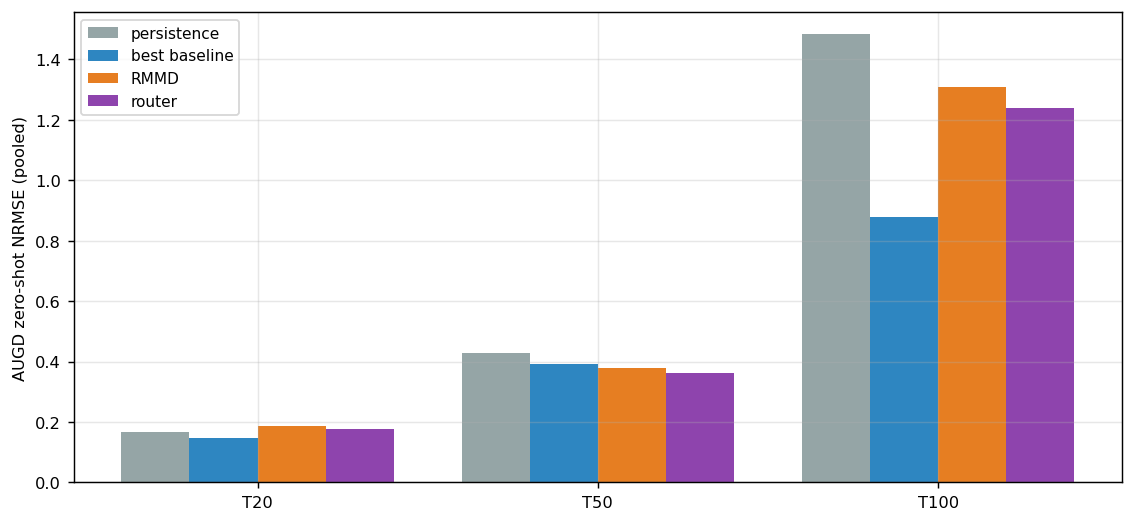

In [25]:
# ED8: driver-keyed router vs fixed policies on AUGD zero-shot.
r = data.get('router'); au = (r or {}).get('per_dataset', {}).get('augd', {})
exA = data.get('extrap_augd'); Hs = [20, 50, 100]
def g(dd, h): return (dd or {}).get(str(h))
router = [g(au.get('router_zeroshot_pooled'), h) for h in Hs]
rmmd = [g(au.get('rmmd_pooled'), h) for h in Hs]
bp = au.get('baselines_pooled', {})
bestb = []
for h in Hs:
    vals = [g(bp[m], h) for m in bp if m != 'RMMD' and g(bp[m], h) is not None]
    fv = fno_best('augd', h)
    if fv is not None: vals.append(fv)
    bestb.append(min(vals) if vals else None)
pers = [None] * len(Hs)
if exA:
    MA = exA['models']; fkA = [k for k in MA if k == 'full' or k.startswith('full_')][0]
    pers = [((MA[fkA].get('holdout') or {}).get(str(h)) or {}).get('persistence') for h in Hs]
series = [('persistence', '#95a5a6', pers), ('best baseline', '#2e86c1', bestb), ('RMMD', '#e67e22', rmmd), ('router', '#8e44ad', router)]
fig, ax = plt.subplots(figsize=(8.8, 4.1)); x = np.arange(len(Hs)); w = 0.2
for i, (nm, c, v) in enumerate(series):
    ax.bar(x + (i - 1.5) * w, [vv if vv is not None else np.nan for vv in v], w, color=c, label=nm)
ax.set_xticks(x); ax.set_xticklabels([f'T{h}' for h in Hs]); ax.set_ylabel('AUGD zero-shot NRMSE (pooled)')
ax.legend(fontsize=8.5)
auc = ((data.get('buttress') or {}).get('B_decision_theoretic', {}) or {}).get('alpha_winner_pred_AUC')
sub = f'winner-predictability AUC = {auc:.2f} (5-fold CV); ' if auc else ''
ax.set_title(f'ED8 — the driver-keyed router vs fixed policies (AUGD, zero-shot)\n{sub}θ=2.65 on rel_ptp, applied blind', fontsize=8.6)
fig.tight_layout(); savefig(fig, 'fig_ED8_router'); plt.show()

## ED9 — machine characteristics table (R₀, a, shots, off-diag frac, crossover, probe; LaTeX to tables/)

In [26]:
# ED9: per-machine characteristics (size, off-diagonal fraction, crossover, nonlocality).
ue = data.get('universality_emergent') or {}; up = data.get('lomo') or {}; b = data.get('buttress') or {}
def _scalar(x):
    if isinstance(x, dict): x = list(x.values())
    if isinstance(x, list): return (float(np.mean(x)) if x else None)
    return x
R0 = ue.get('r_major_per_machine', {}); am = ue.get('a_minor_per_machine', {}); sc = ue.get('shot_counts', {})
odf_e = ue.get('offdiag_frac_per_model', {})
pm_up = up.get('per_machine', {}); au = (b.get('A_ustar') or {}).get('per_machine', {}); cp = (b.get('C_nonlocality') or {}).get('per_machine_partial', {})
machs = sorted(set(list(R0) + list(pm_up) + list(au)))
f = lambda x, dd=3: '--' if (x is None or (isinstance(x, float) and x != x)) else f'{x:.{dd}f}'
print('ED9 — machine characteristics:')
print(f"  {'machine':7} {'shots':>6} {'R0(m)':>6} {'a(m)':>6} {'R0/a':>5} {'offdiagF':>9} {'crossover':>10} {'probe rho':>10}")
Lx = ['\\begin{tabular}{lccccccc}', '\\toprule',
      'Machine & shots & $R_0$(m) & $a$(m) & $R_0/a$ & off-diag frac & crossover $\\omega_d$ & probe $\\rho$ \\\\', '\\midrule']
for m in machs:
    shots = (pm_up.get(m, {}) or {}).get('n_shots') or _scalar(sc.get(m))
    r0 = R0.get(m); a_ = am.get(m); asp = (r0 / a_) if (r0 and a_) else None
    odf = (pm_up.get(m, {}) or {}).get('offdiag_frac')
    if odf is None: odf = _scalar(odf_e.get(m))
    xo = (au.get(m, {}) or {}).get('u_obs_dres_signchange'); rho = (cp.get(m, {}) or {}).get('partial_rho')
    sh = '--' if shots is None else str(int(shots))
    print(f"  {m:7} {sh:>6} {f(r0,2):>6} {f(a_,2):>6} {f(asp,1):>5} {f(odf):>9} {f(xo,2):>10} {f(rho,2):>10}")
    Lx.append(f"{m} & {sh} & {f(r0,2)} & {f(a_,2)} & {f(asp,1)} & {f(odf)} & {f(xo,2)} & {f(rho,2)} \\\\")
Lx += ['\\bottomrule', '\\end{tabular}',
       '% R0,a from universality_emergent (5 training machines); shots+offdiag(fold) from universality_predictive;',
       '% crossover+probe from buttress. EAST/AUGD are holdouts (no R0/a in the emergent scan). q, B not in the pipeline.']
(TAB / 'ED9_machine_characteristics.tex').write_text('\n'.join(Lx))
print('  -> tables/ED9_machine_characteristics.tex')


ED9 — machine characteristics:
  machine  shots  R0(m)   a(m)  R0/a  offdiagF  crossover  probe rho
  AUGD       173     --     --    --     0.980         --       0.26
  CMOD       208   0.68   0.21   3.2     0.984       0.25         --
  D3D        502   1.67   0.67   2.5     0.983       1.15       0.11
  EAST       553     --     --    --     0.980       0.82       0.17
  HL2A       509   0.67   0.22   3.0     0.981       0.21       0.45
  KSTR       353   1.80   0.50   3.6     0.976         --      -0.13
  NSTX       603   0.85   0.67   1.3     0.971       0.70      -0.08
  -> tables/ED9_machine_characteristics.tex


## ED10 — structural universality (sharing-free off-diagonal fraction per fold + kernel-param universality)

In [27]:
# ED10: off-diagonal Frobenius fraction across independent folds (structural universality).
up = data.get('lomo') or {}; ue = data.get('universality_emergent') or {}; sut = data.get('sut') or {}
def _mean(x):
    if isinstance(x, dict): x = list(x.values())
    if isinstance(x, list): return (float(np.mean(x)) if x else None)
    return x
od_fold = {m: v.get('offdiag_frac') for m, v in up.get('per_machine', {}).items() if v.get('offdiag_frac') is not None}
od_emerg = {m: _mean(v) for m, v in ue.get('offdiag_frac_per_model', {}).items()}
print('ED10 — off-diagonal Frobenius fraction (sharing-free):')
print('  per LOMO fold (independent fits):', {m: round(v, 3) for m, v in od_fold.items()})
print('  emergent single-machine scan     :', {m: (round(v, 3) if v is not None else None) for m, v in od_emerg.items()})
allv = [v for v in list(od_fold.values()) + list(od_emerg.values()) if v is not None]
if allv:
    print(f'  -> range {min(allv):.3f}-{max(allv):.3f}, median {np.median(allv):.3f} (expect ~0.982-0.990)')
fam = sut.get('families', {})
print('\n  kernel-parameter universality (between-machine std/mean; lower = more universal):')
for k, nice in [('res_gammas', 'resonance widths gamma_k'), ('res_weights', 'resonance weights a_k'), ('diss_rates', 'dissipation rates')]:
    som = ((fam.get(k, {}) or {}).get('universality', {}) or {}).get('std_over_mean')
    if som is not None:
        print(f'    {nice:26s} std/mean = {_mean(som):.3f}')
Lx = ['\\begin{tabular}{lc}', '\\toprule', 'LOMO fold (independent) & off-diagonal Frobenius fraction \\\\', '\\midrule']
for m, v in sorted(od_fold.items()): Lx.append(f'{m} & {v:.3f} \\\\')
Lx += ['\\bottomrule', '\\end{tabular}', '% Independent fits (no shared parameters) all converge to ~0.98 off-diagonal.']
(TAB / 'ED10_structural_universality.tex').write_text('\n'.join(Lx))
print('  -> tables/ED10_structural_universality.tex')


ED10 — off-diagonal Frobenius fraction (sharing-free):
  per LOMO fold (independent fits): {'CMOD': 0.984, 'D3D': 0.983, 'HL2A': 0.981, 'KSTR': 0.976, 'NSTX': 0.971, 'EAST': 0.98, 'AUGD': 0.98}
  emergent single-machine scan     : {'CMOD': 0.989, 'D3D': 0.984, 'HL2A': 0.984, 'KSTR': 0.988, 'NSTX': 0.987}
  -> range 0.971-0.989, median 0.983 (expect ~0.982-0.990)

  kernel-parameter universality (between-machine std/mean; lower = more universal):
    resonance widths gamma_k   std/mean = 0.240
    resonance weights a_k      std/mean = 0.003
    dissipation rates          std/mean = 0.004
  -> tables/ED10_structural_universality.tex


## Fig 4(a) / ED5(c) — the ‖D_res‖-vs-nonlocality claim (per-shot scatter not dumped; carried by committed correlations)

In [28]:
# Supporting statistics for the ||D_res|| meter (per-shot scatter not stored).
dr = data.get('buttress') or {}; C = dr.get('C_nonlocality', {})
d2 = (data.get('git_synth') and None)  # placeholder
dre = None
try:
    import json as _j
    dre = _j.load(open(str(REPO / 'STRONG_RMMD' / 'decisive_experiments' / 'results' / 'dres_regime.json')))
except Exception:
    dre = None
print('Fig 4(a)/ED5(c) — the ‖D_res‖ meter, from committed statistics (per-shot scatter not dumped):')
if dre:
    e = dre.get('EXP2_1_dres_vs_independent_drive', {})
    print(f"  EXP-2 (model-free): Spearman(‖D_res‖, PINJ) = {e.get('spearman_dres_vs_PINJ'):.2f} (p={e.get('perm_p_PINJ')}); "
          f"vs PINJ-variability = {e.get('spearman_dres_vs_PINJ_variability'):.2f}")
print(f"  EXP-6 C (nonlocality, drive partialled out): high-drive-tercile partial ρ = {C.get('partial_rho_high_drive_tercile', float('nan')):.2f} "
      f"(p={C.get('high_drive_p')})")
print('  -> the scatter is summarized by these correlations; the per-machine bars are in fig4_nonlocality_probe.')


Fig 4(a)/ED5(c) — the ‖D_res‖ meter, from committed statistics (per-shot scatter not dumped):
  EXP-2 (model-free): Spearman(‖D_res‖, PINJ) = 0.81 (p=0.0); vs PINJ-variability = 0.42
  EXP-6 C (nonlocality, drive partialled out): high-drive-tercile partial ρ = 0.52 (p=4.977935406155559e-22)
  -> the scatter is summarized by these correlations; the per-machine bars are in fig4_nonlocality_probe.


saved figures/fig_ED3_ablation.png|.pdf


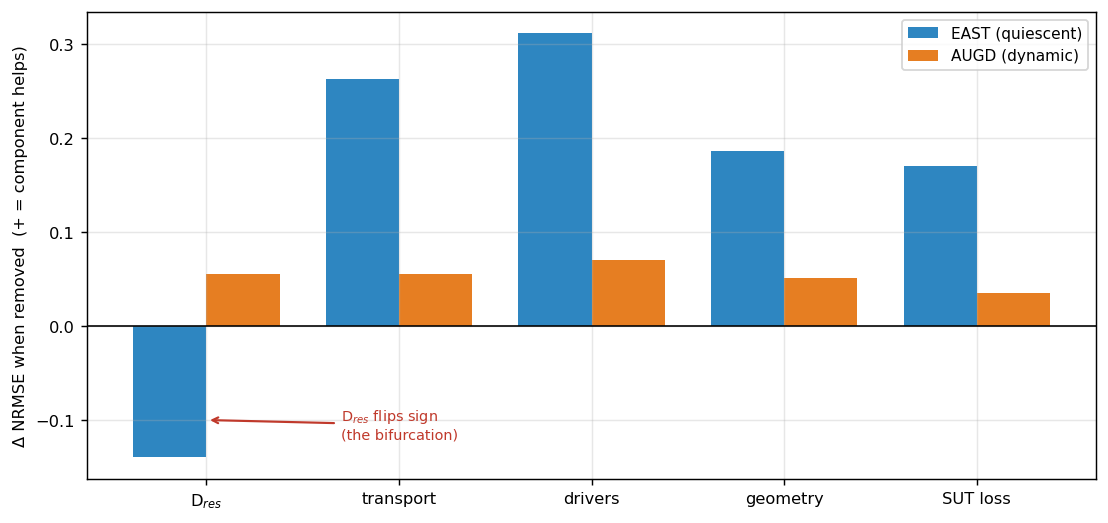

In [29]:
# ED3: component ablations, delta NRMSE per component per holdout (D_res is the only sign-flipping component).
comps = [('D$_{res}$', 'abl_dres'), ('transport', 'abl_transport'), ('drivers', 'abl_drivers'), ('geometry', 'abl_geometry'), ('SUT loss', 'abl_sut')]
H = 100; fig, ax = plt.subplots(figsize=(8.6, 4.1)); x = np.arange(len(comps)); w = 0.38
for j, (tag, ex, col) in enumerate([('EAST (quiescent)', data.get('extrap'), '#2e86c1'), ('AUGD (dynamic)', data.get('extrap_augd'), '#e67e22')]):
    if not ex: continue
    M = ex['models']; fk = [k for k in M if k == 'full' or k.startswith('full_')][0]
    def h(mm): return ((M.get(mm, {}).get('holdout') or {}).get(str(H)) or {}).get('nrmse')
    vals = [(h(ab) - h(fk)) if (h(ab) is not None and h(fk) is not None) else np.nan for _, ab in comps]
    ax.bar(x + (j - 0.5) * w, vals, w, color=col, label=tag)
ax.axhline(0, color='k', lw=0.9); ax.set_xticks(x); ax.set_xticklabels([c for c, _ in comps])
ax.set_ylabel('Δ NRMSE when removed  (+ = component helps)'); ax.legend(fontsize=8.5)
ax.annotate('D$_{res}$ flips sign\n(the bifurcation)', xy=(0, -0.10), xytext=(0.7, -0.12), fontsize=8, color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2))
ax.set_title('ED3 — ablations @T100: D$_{res}$ is the only component whose sign flips across regimes;\nevery other component helps both quiescent and dynamic machines', fontsize=8.7)
fig.tight_layout(); savefig(fig, 'fig_ED3_ablation'); plt.show()


saved figures/fig_quartile_skill.png|.pdf


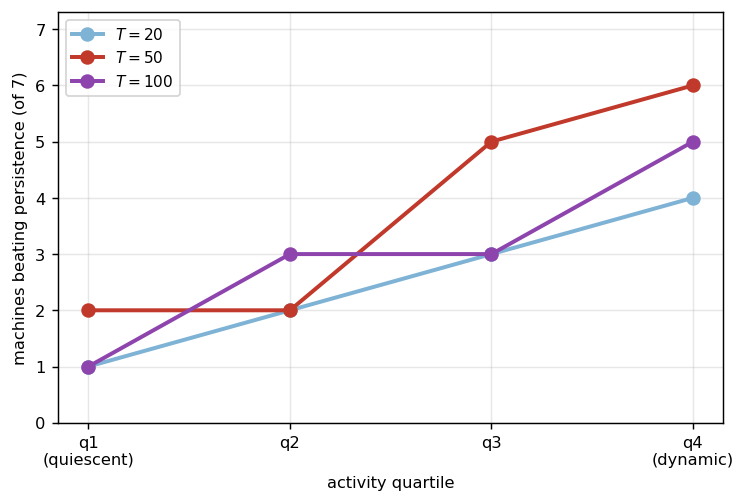

T20 machines beating persistence: [1, 2, 3, 4]
T50 machines beating persistence: [2, 2, 5, 6]
T100 machines beating persistence: [1, 3, 3, 5]


In [30]:
# Activity-stratified transfer: number of LOMO machines beating persistence, by activity quartile.
up = data.get('lomo'); pm = (up or {}).get('per_machine', {})
if pm:
    Qs = ['q1', 'q2', 'q3', 'q4']; machs = sorted(pm); xs = np.arange(1, 5)
    fig, ax = plt.subplots(figsize=(6.6, 4.1))
    for H, c in [('20', '#7fb3d5'), ('50', '#c0392b'), ('100', '#8e44ad')]:
        frac = [sum(1 for m in machs if ((((pm[m].get('correct_quartile_skill') or {}).get(H, {}) or {}).get(q)) or -9) > 0) for q in Qs]
        ax.plot(xs, frac, '-o', lw=2.2, ms=7, color=c, label=f'$T{{=}}{H}$')
    ax.set_xticks(xs); ax.set_xticklabels(['q1\n(quiescent)', 'q2', 'q3', 'q4\n(dynamic)'])
    ax.set_ylabel('machines beating persistence (of 7)'); ax.set_xlabel('activity quartile')
    ax.set_ylim(0, 7.3); ax.set_yticks(range(0, 8)); ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=8.5, loc='upper left')
    savefig(fig, 'fig_quartile_skill'); plt.show()
    for H in ('20', '50', '100'):
        print(f'T{H} machines beating persistence:', [sum(1 for m in machs if ((((pm[m].get("correct_quartile_skill") or {}).get(H,{}) or {}).get(q)) or -9)>0) for q in Qs])

In [31]:
# Activity-stratified NRMSE by quartile at T50, RMMD vs persistence, per holdout (LaTeX table).
Qs = ['q1', 'q2', 'q3', 'q4']
def _bf(M):
    c = [m for m in M if m == 'full' or m.startswith('full_')]
    return min(c, key=lambda m: (((M[m].get('holdout') or {}).get('50') or {}).get('nrmse', 9))) if c else None
for tag, ex in [('EAST', data.get('extrap')), ('AUGD', data.get('extrap_augd'))]:
    if not ex: continue
    M = ex['models']; rm = _bf(M)
    def md(q): return (((M[rm].get('holdout_activity_stratified') or {}).get('50', {}).get(q)) or {})
    L = ['\\begin{tabular}{lcccc}', '\\toprule',
         f'\\multicolumn{{5}}{{c}}{{{tag} --- zero-shot NRMSE by activity quartile ($T{{=}}50$)}} \\\\', '\\midrule',
         'Quartile & $n$ & RMMD & persistence & winner \\\\', '\\midrule']
    for q in Qs:
        dd = md(q); mo = dd.get('model_nrmse'); pe = dd.get('persistence_nrmse'); n = dd.get('n')
        if mo is None: L.append(f'{q} & -- & -- & -- & -- \\\\'); continue
        win = 'RMMD' if mo < pe else 'persist.'
        mo_s = ('\\textbf{%.3f}' % mo) if mo < pe else ('%.3f' % mo)
        pe_s = ('\\textbf{%.3f}' % pe) if pe < mo else ('%.3f' % pe)
        lab = {'q1': 'q1 (quiescent)', 'q4': 'q4 (dynamic)'}.get(q, q)
        L.append(f'{lab} & {n} & {mo_s} & {pe_s} & {win} \\\\')
    L += ['\\bottomrule', '\\end{tabular}',
          f'% {tag}: zero-shot NRMSE at T50 by activity quartile; winner bolded. Persistence dominates quiescent EAST; RMMD wins the dynamic AUGD quartiles.']
    (TAB / f'ED_activity_stratified_{tag.lower()}.tex').write_text('\n'.join(L))
    print(f'{tag}:')
    for q in Qs:
        dd = md(q)
        if dd.get('model_nrmse') is not None:
            print(f'  {q}: RMMD {dd["model_nrmse"]:.3f} vs pers {dd["persistence_nrmse"]:.3f} -> {"RMMD" if dd["model_nrmse"]<dd["persistence_nrmse"] else "pers"}')

EAST:
  q1: RMMD 0.126 vs pers 0.000 -> pers
  q2: RMMD 0.142 vs pers 0.004 -> pers
  q3: RMMD 0.213 vs pers 0.079 -> pers
  q4: RMMD 0.659 vs pers 0.590 -> pers
AUGD:
  q1: RMMD 0.036 vs pers 0.040 -> RMMD
  q2: RMMD 0.083 vs pers 0.072 -> pers
  q3: RMMD 0.304 vs pers 0.396 -> RMMD
  q4: RMMD 1.013 vs pers 1.126 -> RMMD
